In [1]:
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from itertools import combinations

In [3]:

def plot_histograms_from_file(pickle_file_path, save_dir, y_max=None):
    """
    Load user representations from a pickle file, compute cosine similarities,
    and plot histograms for all users and pairwise similarities for single users.

    Args:
        pickle_file_path (str): Path to the pickle file containing user representations.
        save_dir (str): Directory to save the histograms.
        y_max (float, optional): Maximum limit for the y-axis. Default is None.

    Returns:
        tuple: Paths to the saved histograms for all users and single user.
    """
    os.makedirs(save_dir, exist_ok=True)

    # Load user representations
    with open(pickle_file_path, 'rb') as f:
        user_representations = pickle.load(f)
    if not isinstance(user_representations, np.ndarray):
        user_representations = np.array(user_representations)

    # Compute mean representation for all users
    mean_representation_all = np.mean(user_representations, axis=0)
    
    # Compute cosine similarities for all users
    cos_similarities_all = []
    for user_rep in user_representations:
        cos_sim = np.sum(user_rep * mean_representation_all, axis=1) / (np.linalg.norm(user_rep, axis=1) * np.linalg.norm(mean_representation_all))
        cos_similarities_all.extend(cos_sim)  # Use extend instead of append to flatten the list

    # Plot histogram for all users (linear scale)
    plt.figure(figsize=(10, 5))
    plt.hist(cos_similarities_all, bins=50, rwidth=0.9)  # Adjust rwidth for wider bars
    plt.title('Cosine Similarities of User Representations (All Users)')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Frequency')
    if y_max is not None:
        plt.ylim(0, y_max)
    all_users_path = os.path.join(save_dir, 'cosine_similarities_all_users.png')
    plt.savefig(all_users_path)
    plt.show()  # Display the histogram
    plt.close()
    print(f'Saved histogram for all users at {all_users_path}')

    # Plot histogram for all users (logarithmic scale)
    plt.figure(figsize=(10, 5))
    plt.hist(cos_similarities_all, bins=50, rwidth=0.9, log=True)  # Adjust rwidth for wider bars
    plt.title('Cosine Similarities of User Representations (All Users) - Log Scale')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Frequency (Log Scale)')
    if y_max is not None:
        plt.ylim(1, y_max)
    all_users_log_path = os.path.join(save_dir, 'cosine_similarities_all_users_log.png')
    plt.savefig(all_users_log_path)
    plt.show()  # Display the histogram
    plt.close()
    print(f'Saved log-scaled histogram for all users at {all_users_log_path}')
    
    # Compute pairwise cosine similarities for individual users
    avg_pairwise_similarities = []
    for user_rep in user_representations:
        pairwise_similarities = []
        for pair in combinations(user_rep, 2):
            cos_sim = np.dot(pair[0], pair[1]) / (np.linalg.norm(pair[0]) * np.linalg.norm(pair[1]))
            pairwise_similarities.append(cos_sim)
        avg_pairwise_similarity = np.mean(pairwise_similarities)
        avg_pairwise_similarities.append(avg_pairwise_similarity)
    
    # Plot histogram of average pairwise cosine similarities (linear scale)
    plt.figure(figsize=(10, 5))
    plt.hist(avg_pairwise_similarities, bins=50, rwidth=0.9)  # Adjust rwidth for wider bars
    plt.title('Average Pairwise Cosine Similarities of Interest Representations (Single User)')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Frequency')
    if y_max is not None:
        plt.ylim(0, y_max)
    single_user_path = os.path.join(save_dir, 'avg_pairwise_cosine_similarities_single_user.png')
    plt.savefig(single_user_path)
    plt.show()  # Display the histogram
    plt.close()
    print(f'Saved histogram for single user at {single_user_path}')

    # Plot histogram of average pairwise cosine similarities (logarithmic scale)
    plt.figure(figsize=(10, 5))
    plt.hist(avg_pairwise_similarities, bins=50, rwidth=0.9, log=True)  # Adjust rwidth for wider bars
    plt.title('Average Pairwise Cosine Similarities of Interest Representations (Single User) - Log Scale')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Frequency (Log Scale)')
    if y_max is not None:
        plt.ylim(1, y_max)
    single_user_log_path = os.path.join(save_dir, 'avg_pairwise_cosine_similarities_single_user_log.png')
    plt.savefig(single_user_log_path)
    plt.show()  # Display the histogram
    plt.close()
    print(f'Saved log-scaled histogram for single user at {single_user_log_path}')

    return all_users_path, all_users_log_path, single_user_path, single_user_log_path


In [5]:

def plot_overlapping_histograms_from_file(pickle_file_path, save_dir, y_max=None):
    """
    Load user representations from a pickle file, compute cosine similarities,
    and plot overlapping histograms for all users and interests.

    Args:
        pickle_file_path (str): Path to the pickle file containing user representations.
        save_dir (str): Directory to save the histograms.
        y_max (float, optional): Maximum limit for the y-axis. Default is None.

    Returns:
        str: Path to the saved histogram.
    """
    os.makedirs(save_dir, exist_ok=True)

    # Load user representations
    with open(pickle_file_path, 'rb') as f:
        user_representations = pickle.load(f)
    if not isinstance(user_representations, np.ndarray):
        user_representations = np.array(user_representations)

    # Compute mean representation for all users
    mean_representation_all = np.mean(user_representations, axis=0)
    
    # Compute cosine similarities for all users
    cos_similarities_all = []
    for user_rep in user_representations:
        cos_sim = np.sum(user_rep * mean_representation_all, axis=1) / (np.linalg.norm(user_rep, axis=1) * np.linalg.norm(mean_representation_all))
        cos_similarities_all.extend(cos_sim)

    # Flatten interest representations for histogram
    interest_representations_flat = user_representations.reshape(-1, user_representations.shape[-1])

    # Compute cosine similarities for interests against the mean representation
    cos_similarities_interests = np.sum(interest_representations_flat * mean_representation_all, axis=1) / \
                                 (np.linalg.norm(interest_representations_flat, axis=1) * np.linalg.norm(mean_representation_all))

    # Plot overlapping histograms for all users and interests (linear scale)
    plt.figure(figsize=(10, 5))
    plt.hist(cos_similarities_all, bins=50, alpha=0.5, label='All Users', color='blue', histtype='stepfilled', rwidth=0.9)
    plt.hist(cos_similarities_interests, bins=50, alpha=0.5, label='Interests', color='orange', histtype='stepfilled', rwidth=0.9)
    plt.title('Cosine Similarities of User Representations and Interests')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Frequency')
    plt.legend(loc='upper right')
    if y_max is not None:
        plt.ylim(0, y_max)
    overlapping_histogram_path = os.path.join(save_dir, 'overlapping_cosine_similarities.png')
    plt.savefig(overlapping_histogram_path)
    plt.show()
    plt.close()
    print(f'Saved overlapping histogram at {overlapping_histogram_path}')

    # Plot overlapping histograms for all users and interests (logarithmic scale)
    plt.figure(figsize=(10, 5))
    plt.hist(cos_similarities_all, bins=50, alpha=0.5, label='All Users', color='blue', histtype='stepfilled', rwidth=0.9, log=True)
    plt.hist(cos_similarities_interests, bins=50, alpha=0.5, label='Interests', color='orange', histtype='stepfilled', rwidth=0.9, log=True)
    plt.title('Cosine Similarities of User Representations and Interests - Log Scale')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Frequency (Log Scale)')
    plt.legend(loc='upper right')
    if y_max is not None:
        plt.ylim(1, y_max)
    overlapping_histogram_log_path = os.path.join(save_dir, 'overlapping_cosine_similarities_log.png')
    plt.savefig(overlapping_histogram_log_path)
    plt.show()
    plt.close()
    print(f'Saved log-scaled overlapping histogram at {overlapping_histogram_log_path}')

    return overlapping_histogram_path, overlapping_histogram_log_path



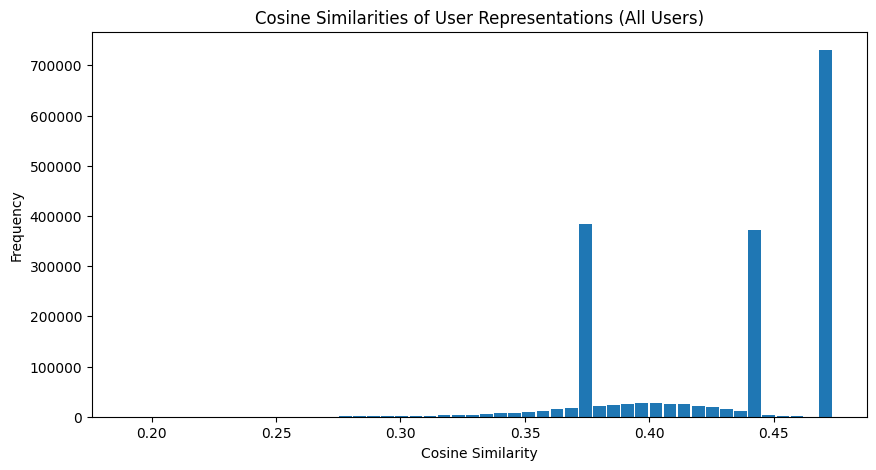

Saved histogram for all users at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/cosine_similarities_all_users.png


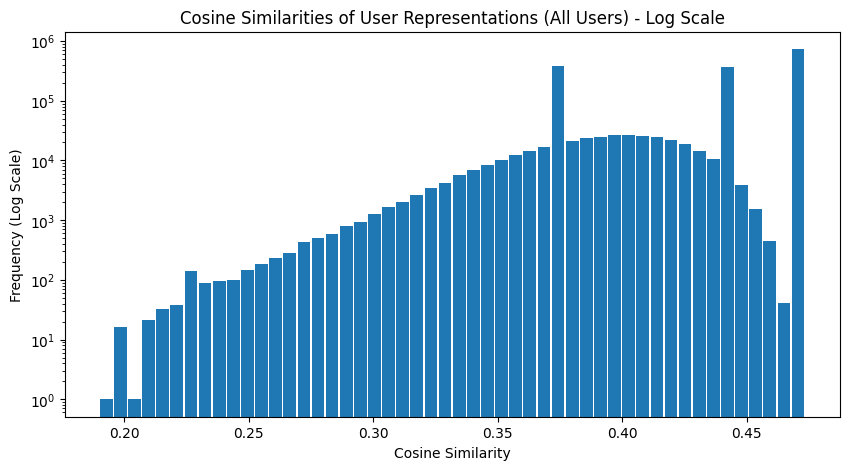

Saved log-scaled histogram for all users at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/cosine_similarities_all_users_log.png


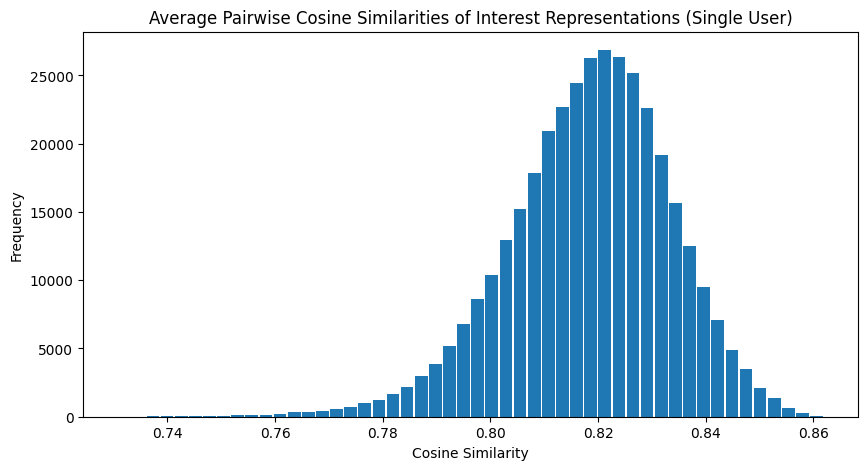

Saved histogram for single user at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/avg_pairwise_cosine_similarities_single_user.png


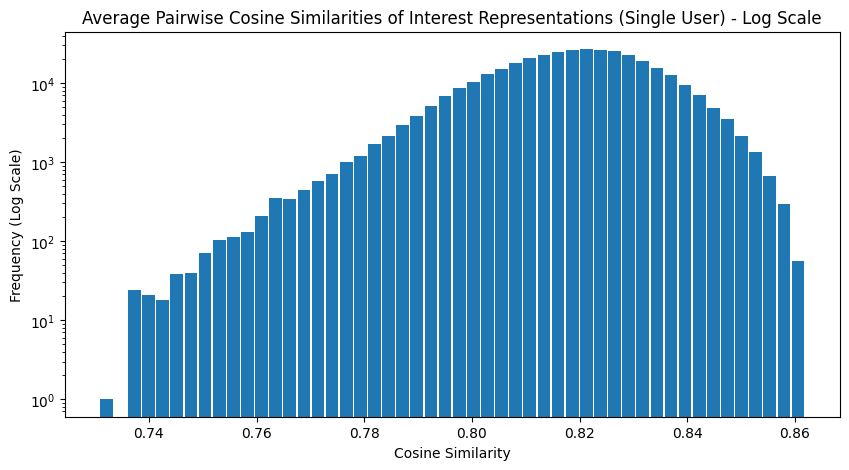

Saved log-scaled histogram for single user at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/avg_pairwise_cosine_similarities_single_user_log.png
All users histogram saved at: /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/cosine_similarities_all_users.png
All users log scale histogram saved at: /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/cosine_similarities_all_users_log.png
Single user histogram saved at: /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/avg_pairwise_cosine_similarities_single_user.png
Single user log scale histogram saved at: /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/avg_pairwise_cosine_similarities_single_user_log.png


In [3]:
#N=5 (Without Disentanglement)
pickle_file_path = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/user_representations.pkl'
save_dir = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations'

all_users_hist_path, all_users_log_hist_path, single_user_hist_path, single_user_log_hist_path = plot_histograms_from_file(
    pickle_file_path, 
    save_dir
)

print(f'All users histogram saved at: {all_users_hist_path}')
print(f'All users log scale histogram saved at: {all_users_log_hist_path}')
print(f'Single user histogram saved at: {single_user_hist_path}')
print(f'Single user log scale histogram saved at: {single_user_log_hist_path}')


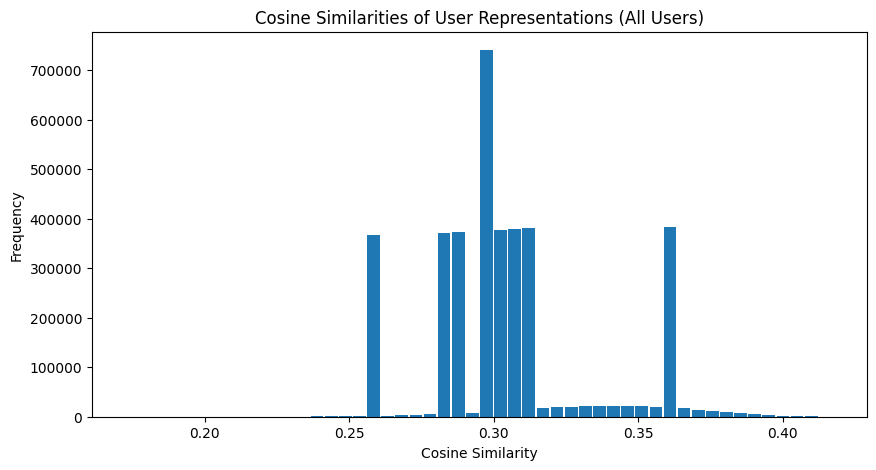

Saved histogram for all users at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/cosine_similarities_all_users.png


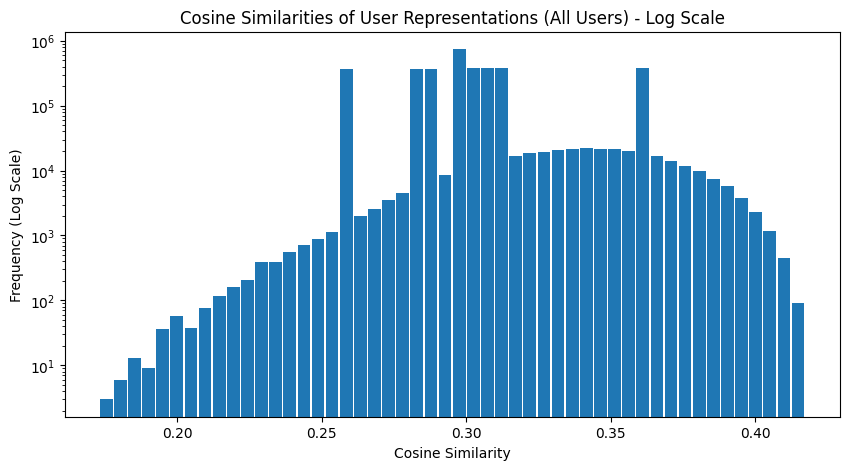

Saved log-scaled histogram for all users at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/cosine_similarities_all_users_log.png


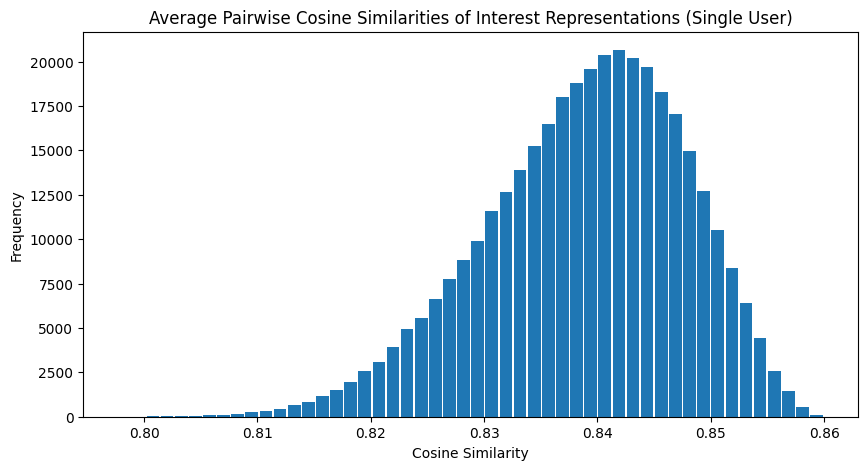

Saved histogram for single user at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/avg_pairwise_cosine_similarities_single_user.png


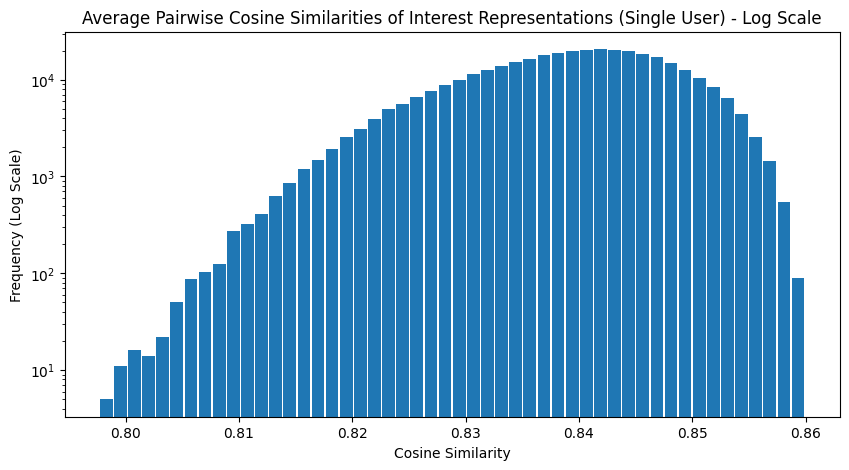

Saved log-scaled histogram for single user at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/avg_pairwise_cosine_similarities_single_user_log.png
All users histogram saved at: /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/cosine_similarities_all_users.png
All users log scale histogram saved at: /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/cosine_similarities_all_users_log.png
Single user histogram saved at: /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/avg_pairwise_cosine_similarities_single_user.png
Single user log scale histogram saved at: /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/avg_pairwise_cosine_similarities_single_user_log.png


In [4]:
#For N=10 (without disentanglement loss)
#Plotting Histograms
pickle_file_path = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/user_representations.pkl'
save_dir = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations'

all_users_hist_path, all_users_log_hist_path, single_user_hist_path, single_user_log_hist_path = plot_histograms_from_file(
    pickle_file_path, 
    save_dir
)

print(f'All users histogram saved at: {all_users_hist_path}')
print(f'All users log scale histogram saved at: {all_users_log_hist_path}')
print(f'Single user histogram saved at: {single_user_hist_path}')
print(f'Single user log scale histogram saved at: {single_user_log_hist_path}')

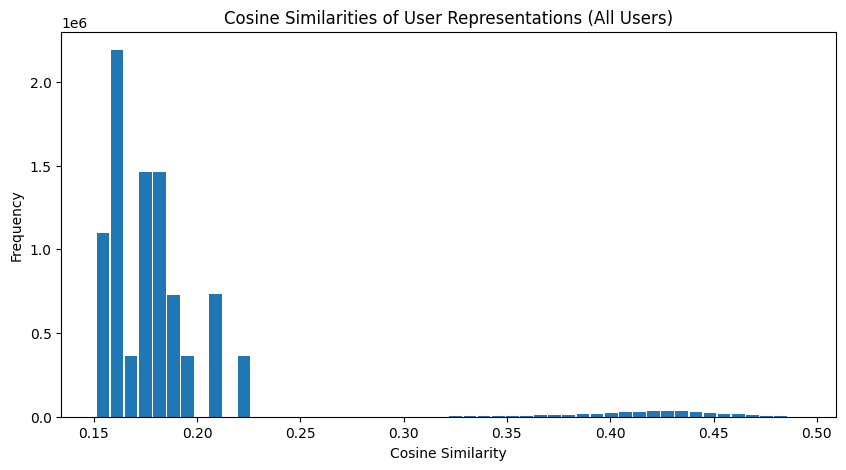

Saved histogram for all users at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/cosine_similarities_all_users.png


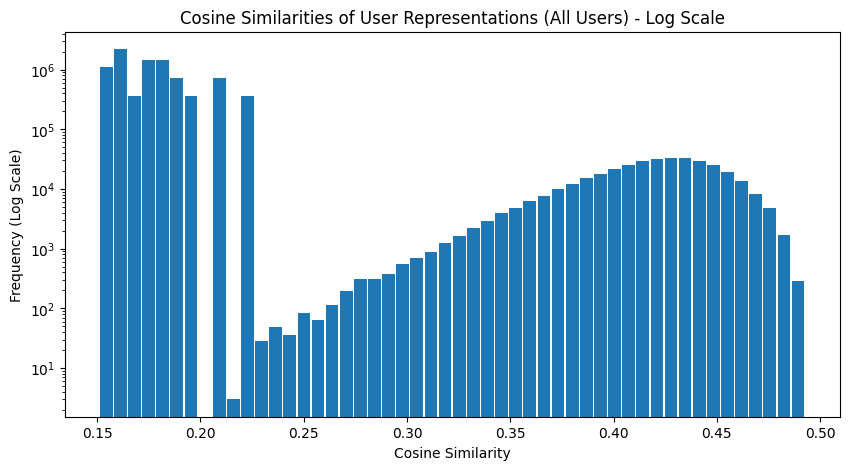

Saved log-scaled histogram for all users at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/cosine_similarities_all_users_log.png


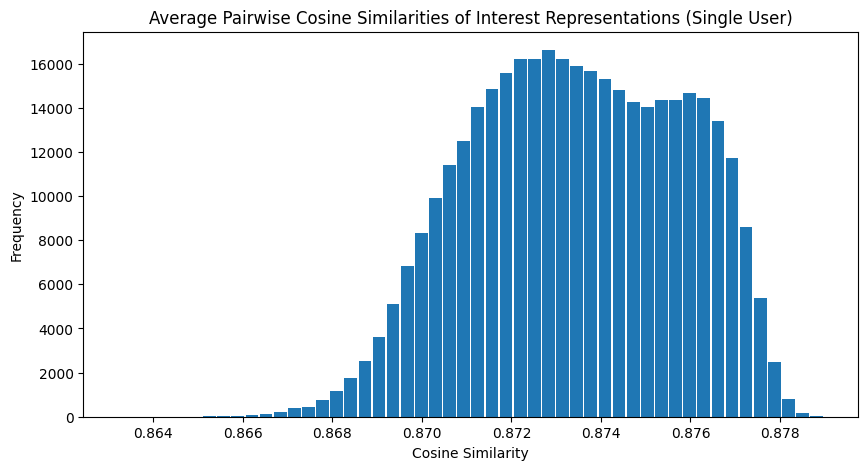

Saved histogram for single user at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/avg_pairwise_cosine_similarities_single_user.png


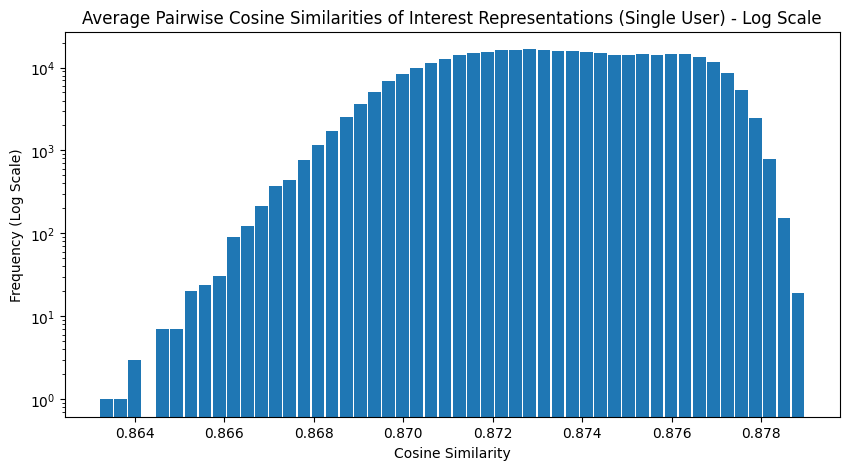

Saved log-scaled histogram for single user at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/avg_pairwise_cosine_similarities_single_user_log.png
All users histogram saved at: /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/cosine_similarities_all_users.png
All users log scale histogram saved at: /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/cosine_similarities_all_users_log.png
Single user histogram saved at: /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/avg_pairwise_cosine_similarities_single_user.png
Single user log scale histogram saved at: /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/avg_pairwise_cosine_similarities_single_user_log.png


In [5]:
#For N=25 (without disentanglement loss)
#Plotting Histograms
pickle_file_path = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/user_representations.pkl'
save_dir = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations'
all_users_hist_path, all_users_log_hist_path, single_user_hist_path, single_user_log_hist_path = plot_histograms_from_file(
    pickle_file_path, 
    save_dir
)

print(f'All users histogram saved at: {all_users_hist_path}')
print(f'All users log scale histogram saved at: {all_users_log_hist_path}')
print(f'Single user histogram saved at: {single_user_hist_path}')
print(f'Single user log scale histogram saved at: {single_user_log_hist_path}')

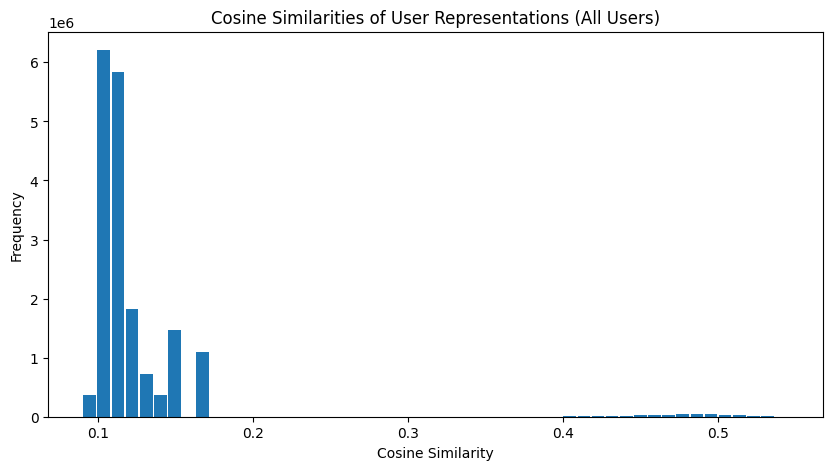

Saved histogram for all users at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/cosine_similarities_all_users.png


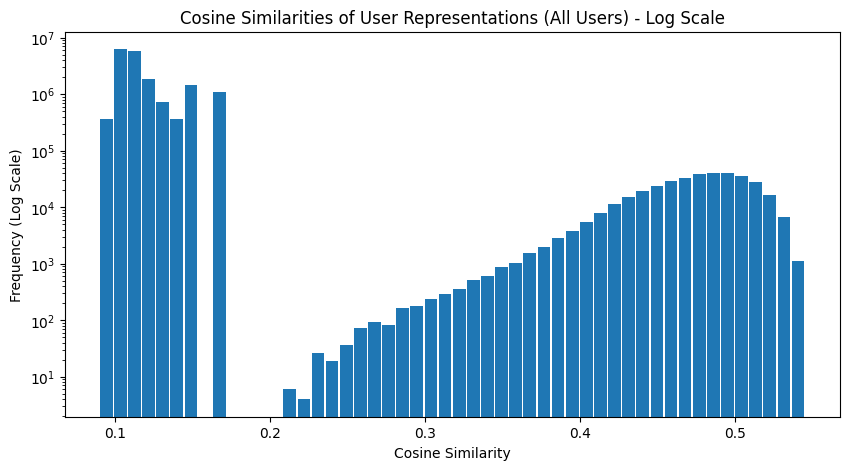

Saved log-scaled histogram for all users at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/cosine_similarities_all_users_log.png


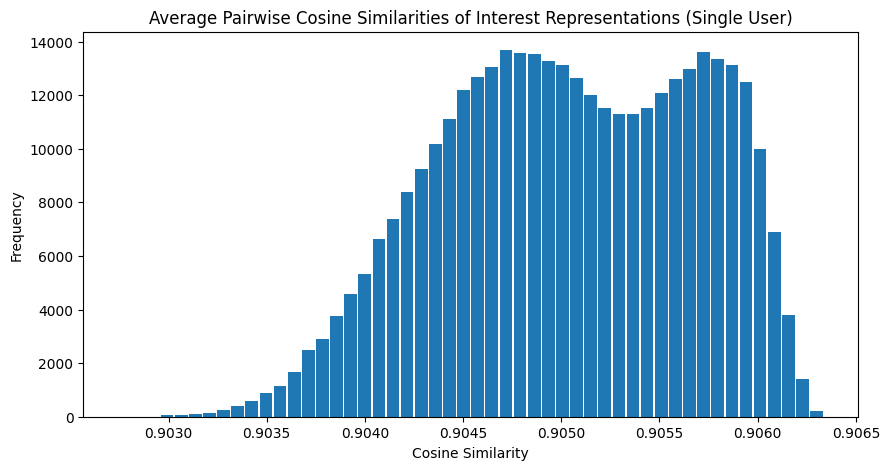

Saved histogram for single user at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/avg_pairwise_cosine_similarities_single_user.png


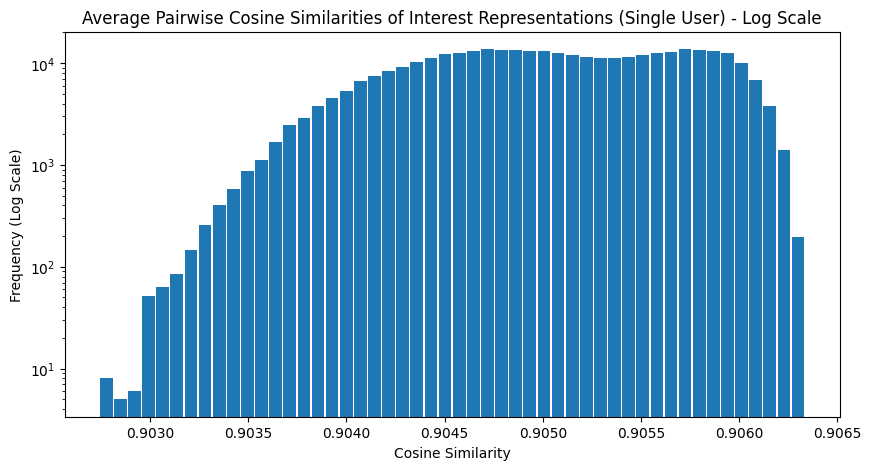

Saved log-scaled histogram for single user at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/avg_pairwise_cosine_similarities_single_user_log.png
All users histogram saved at: /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/cosine_similarities_all_users.png
All users log scale histogram saved at: /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/cosine_similarities_all_users_log.png
Single user histogram saved at: /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/avg_pairwise_cosine_similarities_single_user.png
Single user log scale histogram saved at: /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/avg_pairwise_cosine_similarities_single_user_log.png


In [3]:
#For N=50 (without disentanglement loss)
#Plotting Histograms
pickle_file_path = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/user_representations.pkl'
save_dir = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations'
all_users_hist_path, all_users_log_hist_path, single_user_hist_path, single_user_log_hist_path = plot_histograms_from_file(
    pickle_file_path, 
    save_dir
)

print(f'All users histogram saved at: {all_users_hist_path}')
print(f'All users log scale histogram saved at: {all_users_log_hist_path}')
print(f'Single user histogram saved at: {single_user_hist_path}')
print(f'Single user log scale histogram saved at: {single_user_log_hist_path}')

In [2]:
def plot_tsne(user_representations, tsne_perplexity, tsne_learning_rate, sample_size=1000):
    """
    Plots t-SNE for user representations and displays the plot.

    Args:
        user_representations (np.ndarray): User representations.
        tsne_perplexity (int): Perplexity parameter for t-SNE.
        tsne_learning_rate (int): Learning rate parameter for t-SNE.
        sample_size (int): Number of samples to use for t-SNE. Default is 1000.
    """
    if not isinstance(user_representations, np.ndarray):
        user_representations = np.array(user_representations)
    
    if user_representations.shape[0] > sample_size:
        indices = np.random.choice(user_representations.shape[0], sample_size, replace=False)
        user_representations_sample = user_representations[indices]
    else:
        user_representations_sample = user_representations
    
    # Flatten the user representations for t-SNE
    user_representations_flat = user_representations_sample.reshape(-1, user_representations_sample.shape[-1])
    
    # t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=tsne_perplexity, learning_rate=tsne_learning_rate, n_jobs=-1)
    user_representations_tsne = tsne.fit_transform(user_representations_flat)

    # Plot t-SNE
    plt.figure(figsize=(10, 5))
    num_interests = user_representations_sample.shape[1]
    for i in range(num_interests):
        plt.scatter(user_representations_tsne[i::num_interests, 0], user_representations_tsne[i::num_interests, 1], alpha=0.5, label=f'Interest {i+1}')
    plt.title(f't-SNE of User Representations (perplexity={tsne_perplexity}, lr={tsne_learning_rate})')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend()
    plt.show()  # Display the plot
    plt.close()

def plot_pca(user_representations, sample_size=1000):
    """
    Plots PCA for user representations and displays the plot.

    Args:
        user_representations (np.ndarray): User representations.
        sample_size (int): Number of samples to use for PCA. Default is 1000.
    """
    if not isinstance(user_representations, np.ndarray):
        user_representations = np.array(user_representations)
    
    if user_representations.shape[0] > sample_size:
        indices = np.random.choice(user_representations.shape[0], sample_size, replace=False)
        user_representations_sample = user_representations[indices]
    else:
        user_representations_sample = user_representations
    
    # Flatten the user representations for PCA
    user_representations_flat = user_representations_sample.reshape(-1, user_representations_sample.shape[-1])

    # PCA
    pca = PCA(n_components=2)
    user_representations_pca = pca.fit_transform(user_representations_flat)

    # Plot PCA
    plt.figure(figsize=(10, 5))
    num_interests = user_representations_sample.shape[1]
    for i in range(num_interests):
        plt.scatter(user_representations_pca[i::num_interests, 0], user_representations_pca[i::num_interests, 1], alpha=0.5, label=f'Interest {i+1}')
    plt.title('PCA of User Representations')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend()
    plt.show()  # Display the plot
    plt.close()

Running t-SNE with perplexity=10 and learning_rate=50


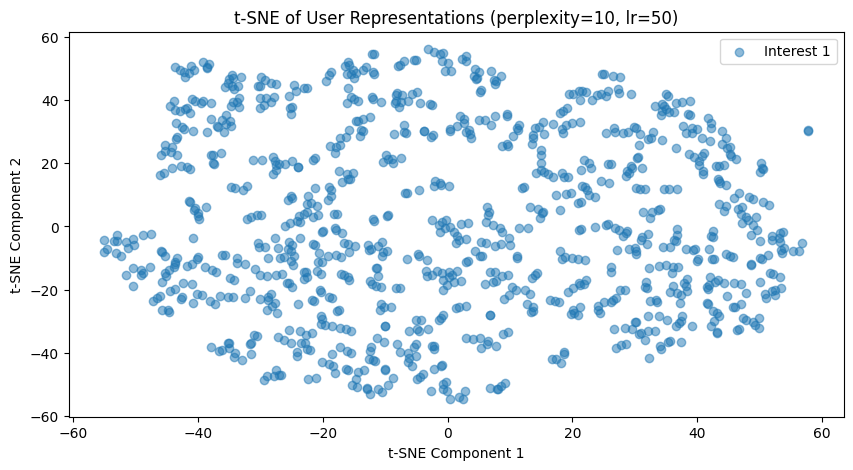

Running t-SNE with perplexity=20 and learning_rate=300


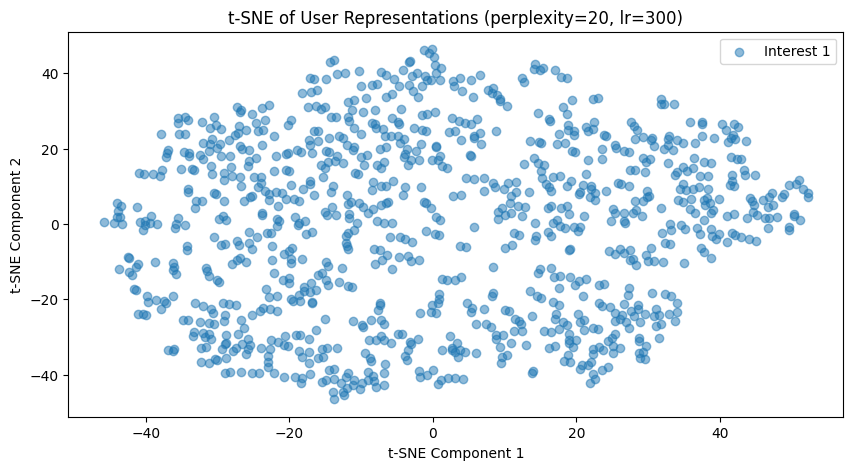

Running t-SNE with perplexity=30 and learning_rate=200


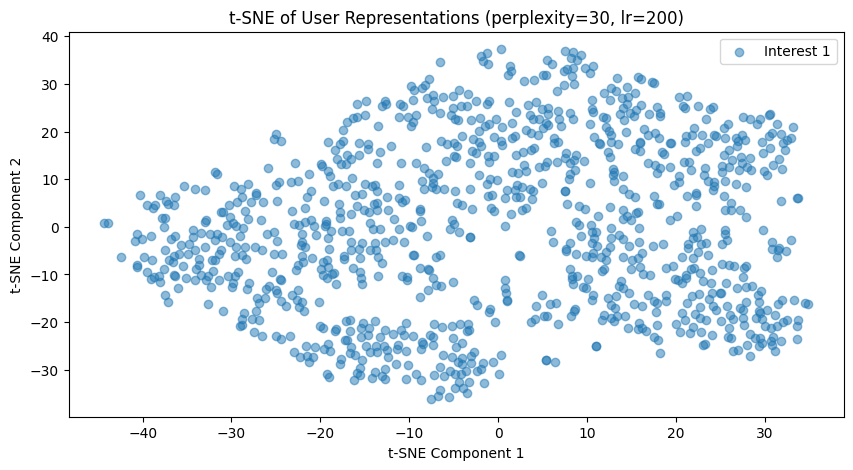

Running t-SNE with perplexity=40 and learning_rate=150


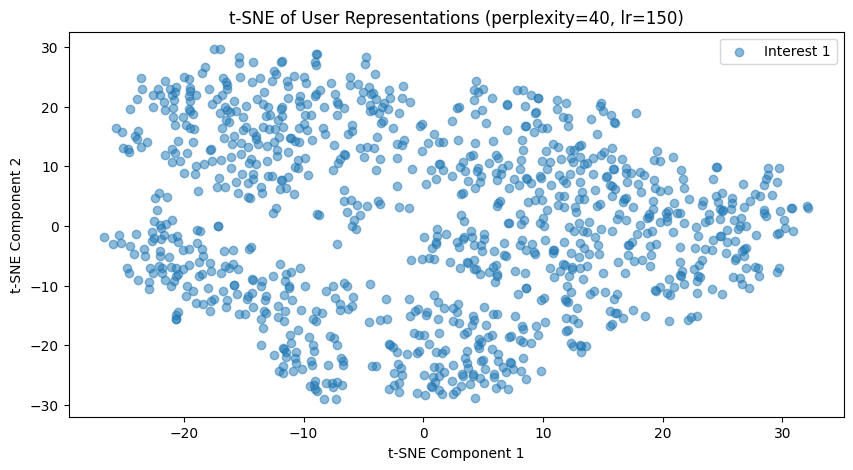

Running t-SNE with perplexity=40 and learning_rate=300


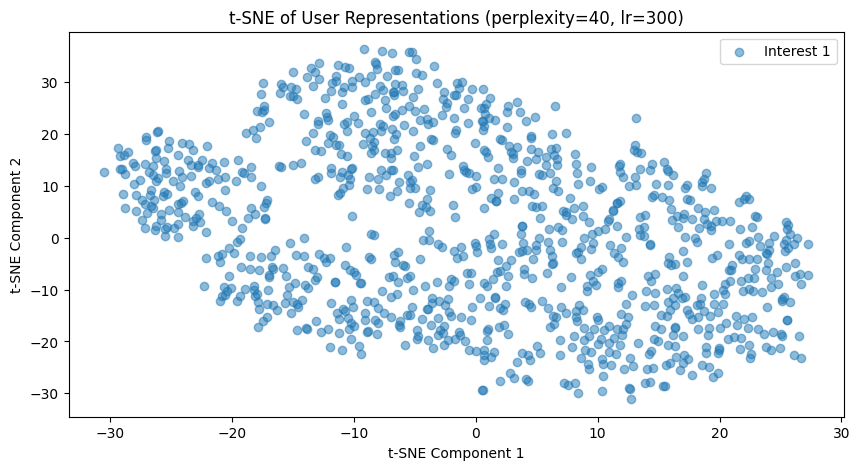

Running t-SNE with perplexity=50 and learning_rate=100


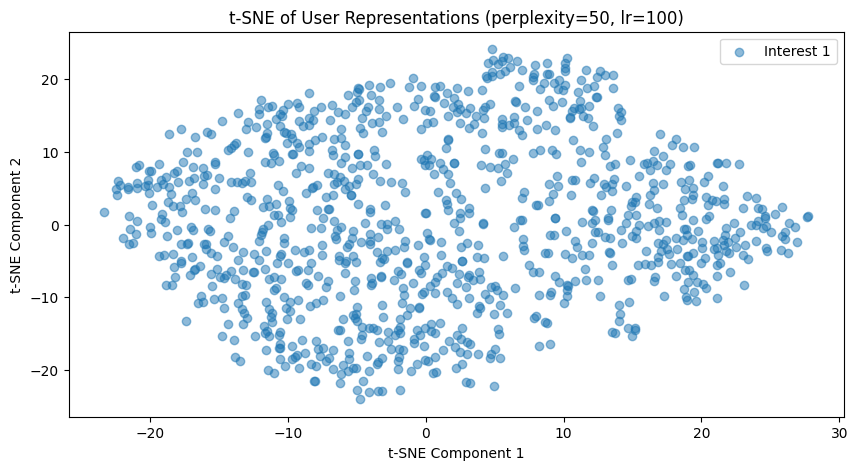

Running t-SNE with perplexity=50 and learning_rate=400


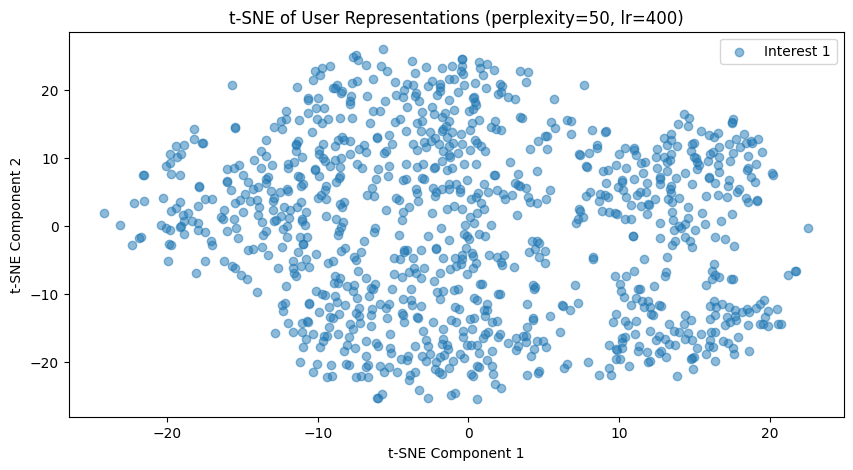

Running t-SNE with perplexity=60 and learning_rate=500


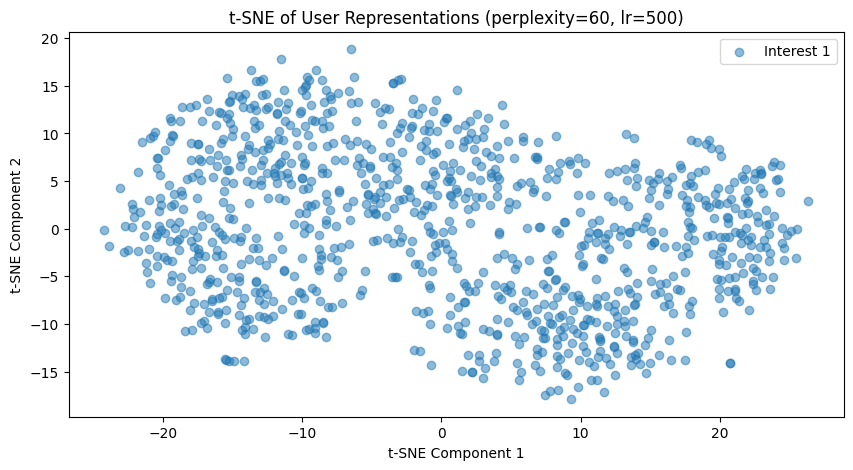

In [5]:
#t-SNE and PCA plots for N=1 (without disentanglement loss)
pickle_file_path = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_bce_N1/user_representations.pkl'
with open(pickle_file_path, 'rb') as f:
    user_representations = pickle.load(f)

# Define t-SNE parameter combinations
combinations = [(10,50), (20,300),(30, 200), (40,150), (40, 300), (50,100), (50, 400), (60, 500)]

# Plot t-SNE and PCA for each combination
for perplexity, learning_rate in combinations:
    print(f"Running t-SNE with perplexity={perplexity} and learning_rate={learning_rate}")
    plot_tsne(user_representations, perplexity, learning_rate)

Running t-SNE with perplexity=10 and learning_rate=50


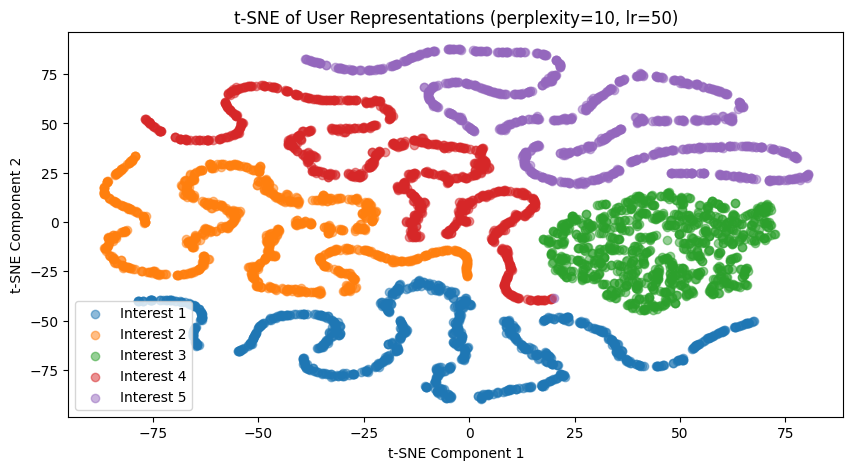

Running t-SNE with perplexity=20 and learning_rate=300


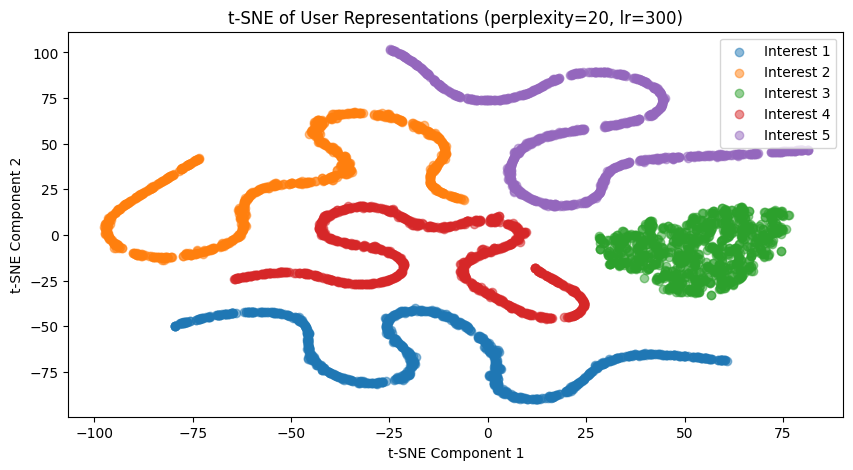

Running t-SNE with perplexity=30 and learning_rate=200


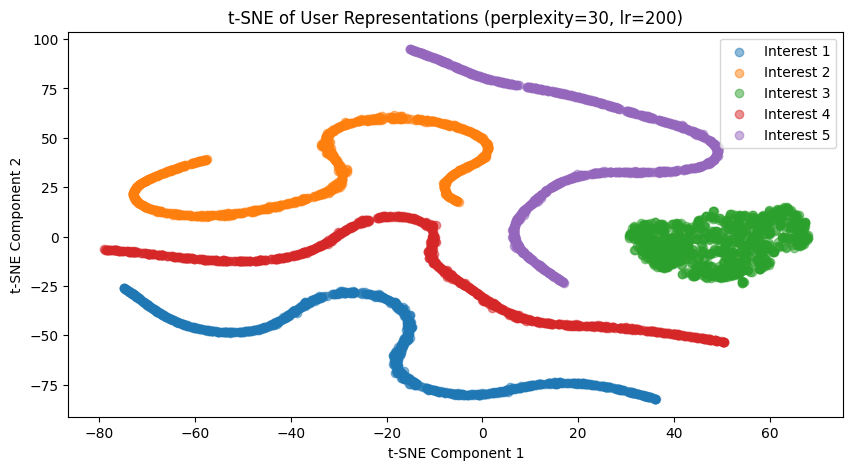

Running t-SNE with perplexity=40 and learning_rate=150


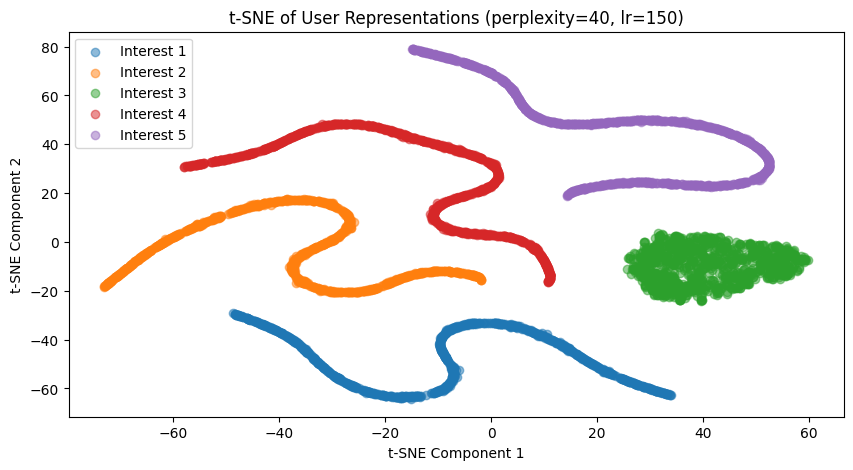

Running t-SNE with perplexity=40 and learning_rate=300


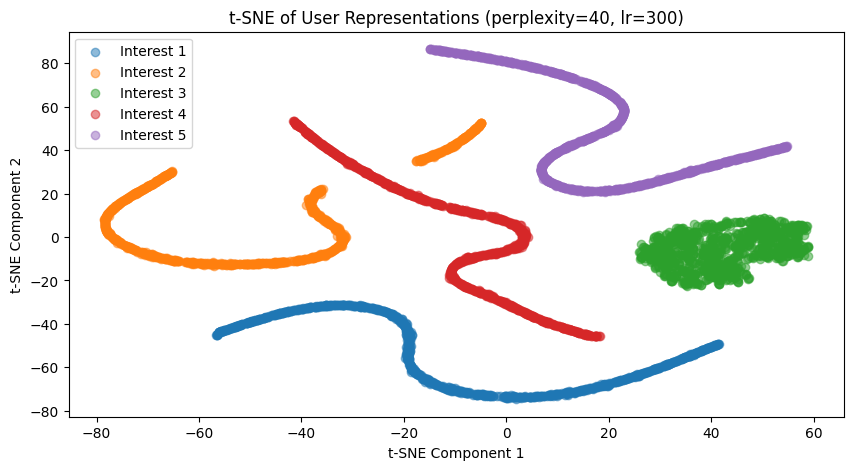

Running t-SNE with perplexity=50 and learning_rate=100


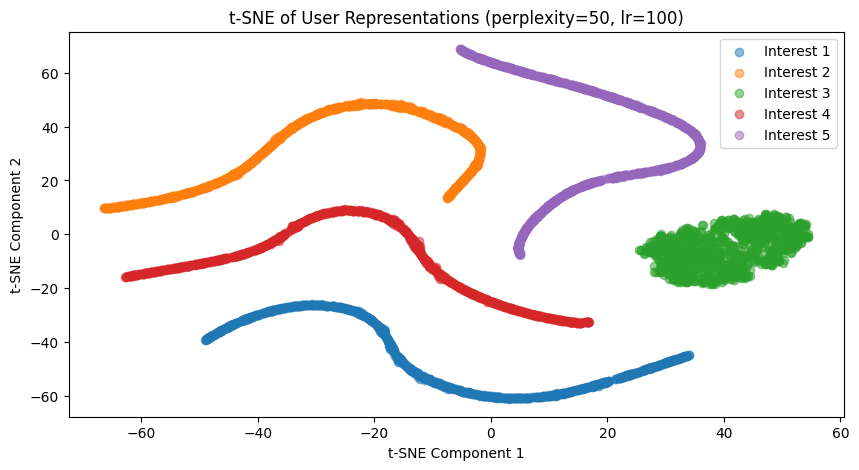

Running t-SNE with perplexity=50 and learning_rate=400


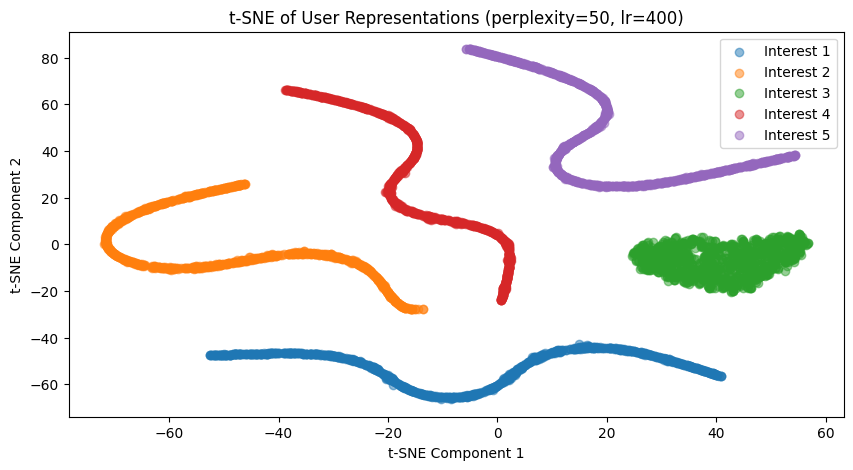

Running t-SNE with perplexity=60 and learning_rate=500


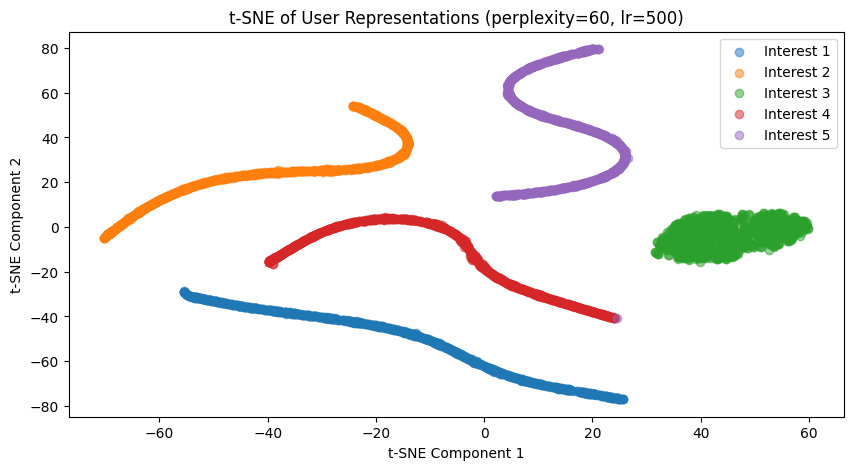

In [6]:
#t-SNE and PCA plots for N=5 (without disentanglement loss)
# Load user representations
pickle_file_path = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/user_representations.pkl'
with open(pickle_file_path, 'rb') as f:
    user_representations = pickle.load(f)

# Define t-SNE parameter combinations
combinations = [(10,50), (20,300),(30, 200), (40,150), (40, 300), (50,100), (50, 400), (60, 500)]

# Plot t-SNE and PCA for each combination
for perplexity, learning_rate in combinations:
    print(f"Running t-SNE with perplexity={perplexity} and learning_rate={learning_rate}")
    plot_tsne(user_representations, perplexity, learning_rate)

Running t-SNE with perplexity=10 and learning_rate=50


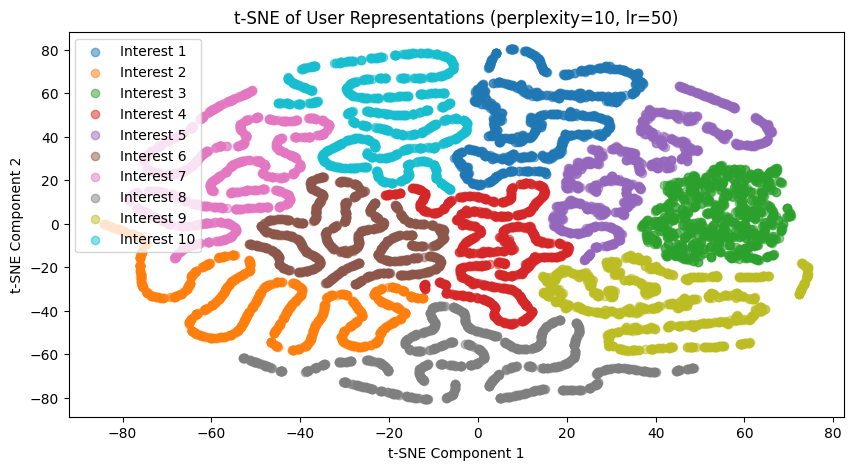

Running t-SNE with perplexity=20 and learning_rate=300


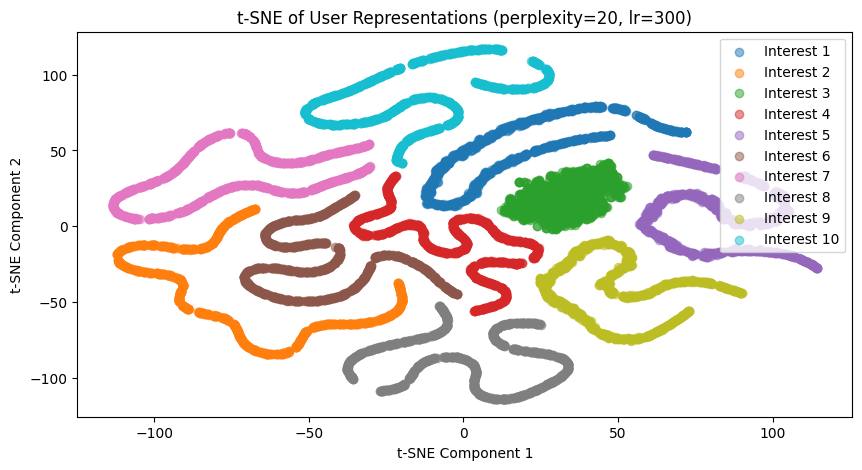

Running t-SNE with perplexity=30 and learning_rate=200


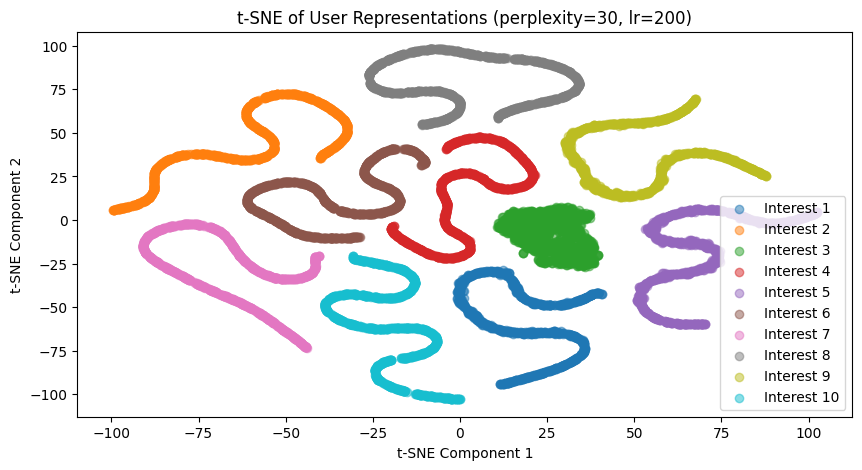

Running t-SNE with perplexity=40 and learning_rate=150


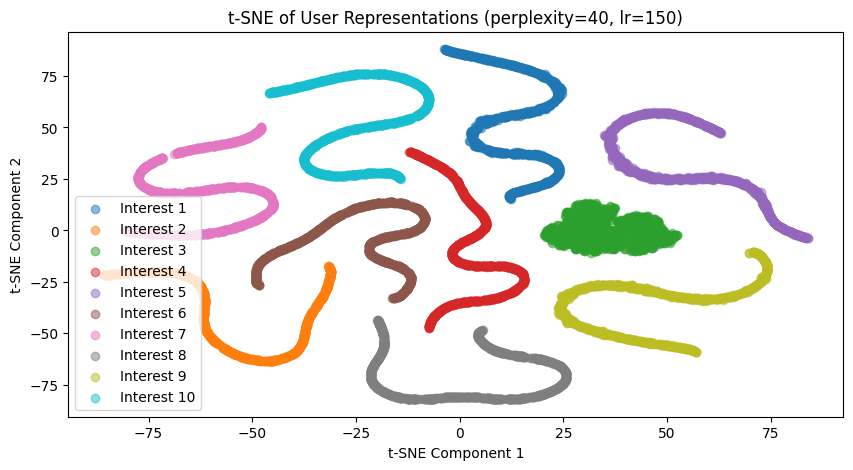

Running t-SNE with perplexity=40 and learning_rate=300


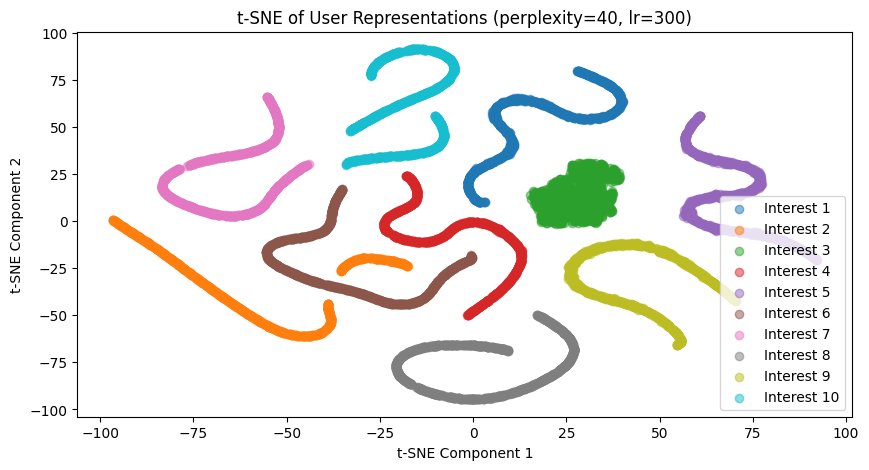

Running t-SNE with perplexity=50 and learning_rate=100


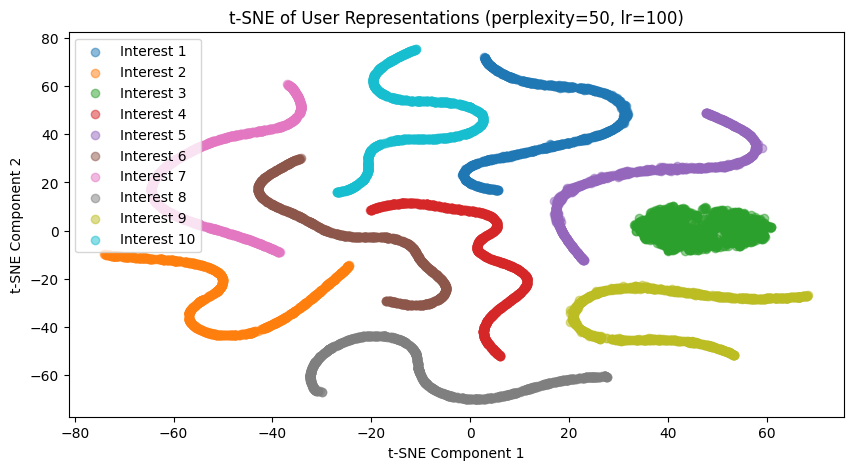

Running t-SNE with perplexity=50 and learning_rate=400


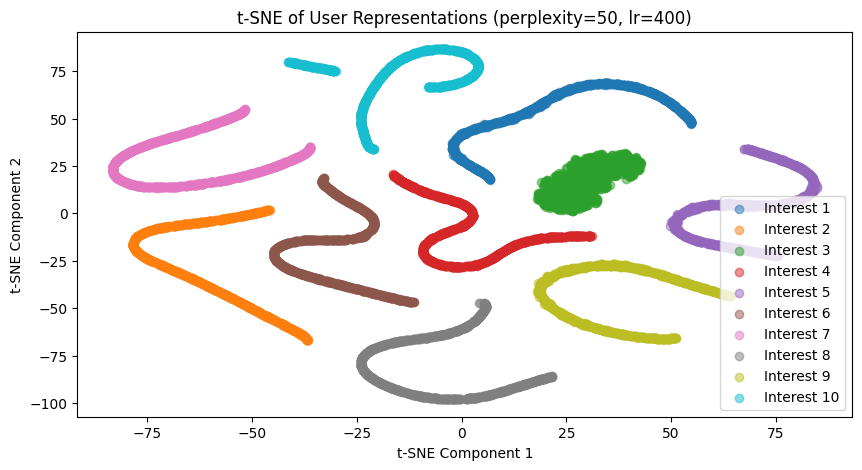

Running t-SNE with perplexity=60 and learning_rate=500


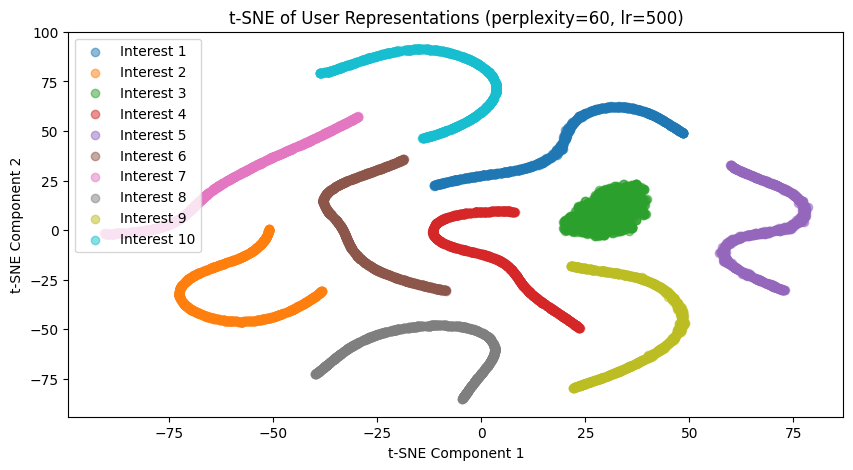

In [7]:
#t-SNE and PCA plots for N=10 (without disentanglement loss)
pickle_file_path = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/user_representations.pkl'
with open(pickle_file_path, 'rb') as f:
    user_representations = pickle.load(f)

# Define t-SNE parameter combinations
combinations = [(10,50), (20,300),(30, 200), (40,150), (40, 300), (50,100), (50, 400), (60, 500)]

# Plot t-SNE and PCA for each combination
for perplexity, learning_rate in combinations:
    print(f"Running t-SNE with perplexity={perplexity} and learning_rate={learning_rate}")
    plot_tsne(user_representations, perplexity, learning_rate)

Running t-SNE with perplexity=10 and learning_rate=50


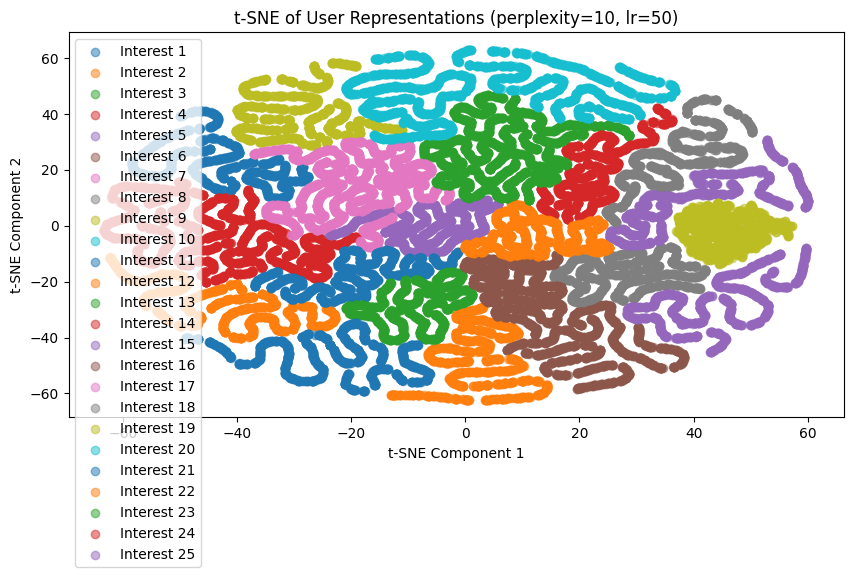

Running t-SNE with perplexity=20 and learning_rate=300


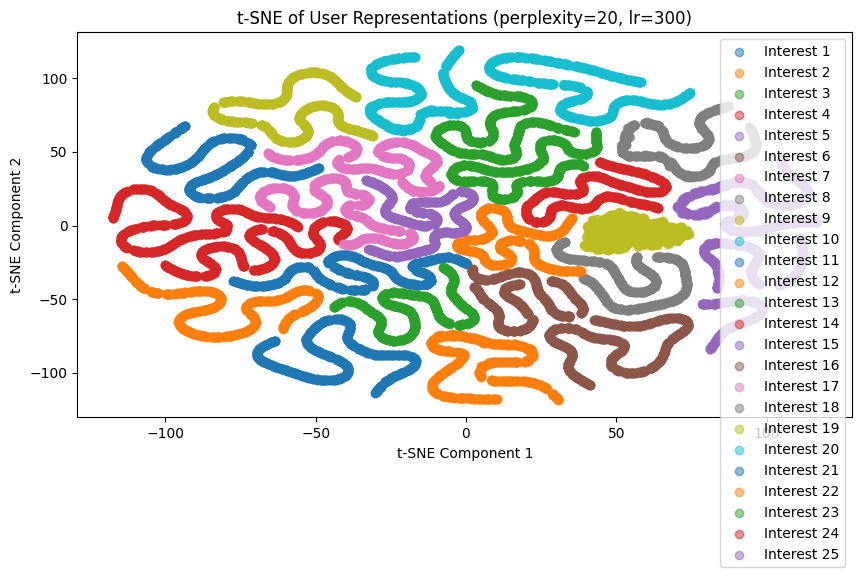

Running t-SNE with perplexity=30 and learning_rate=200


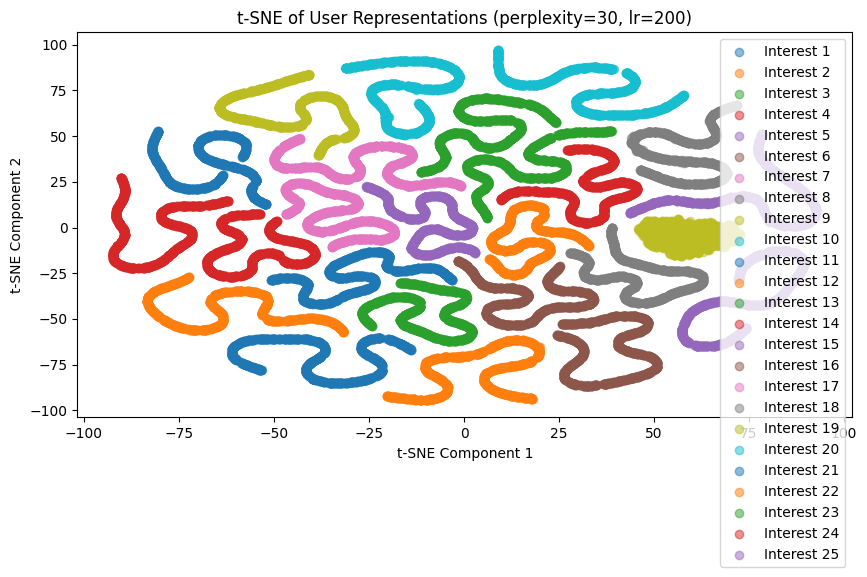

Running t-SNE with perplexity=40 and learning_rate=150


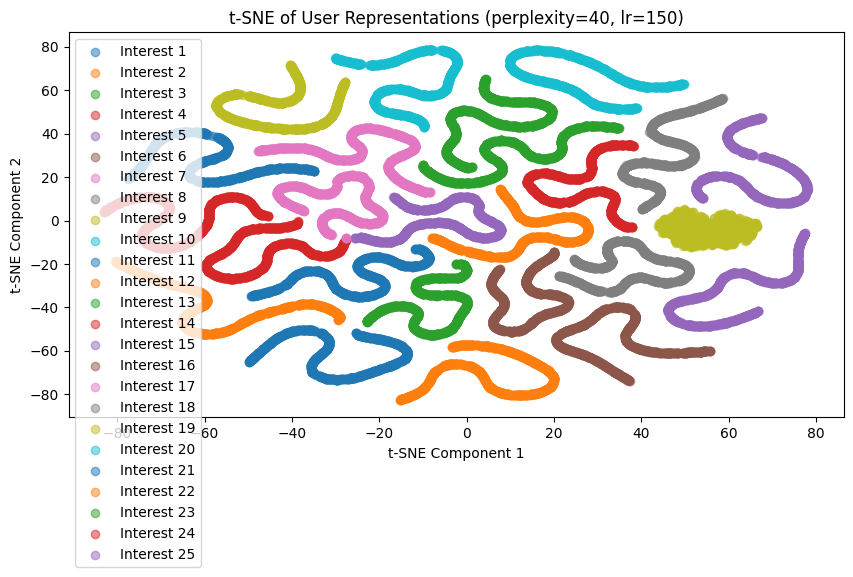

Running t-SNE with perplexity=40 and learning_rate=300


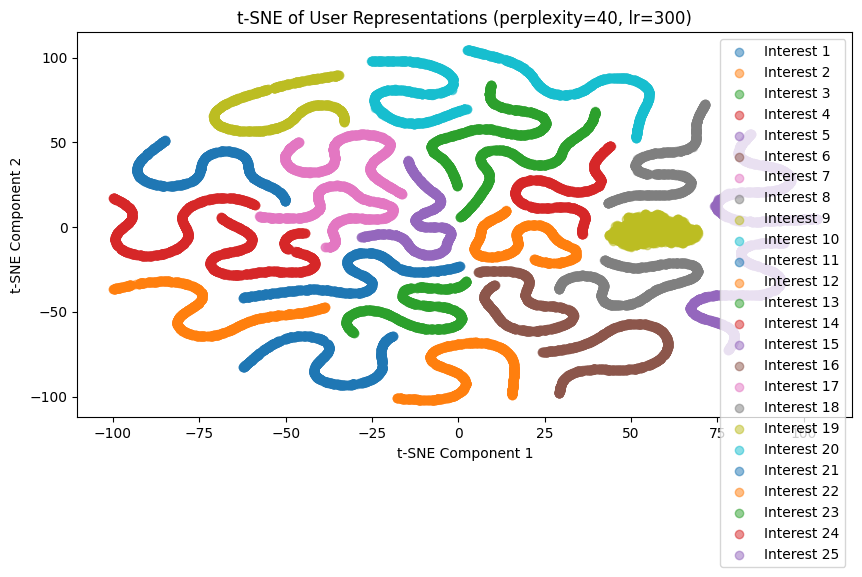

Running t-SNE with perplexity=50 and learning_rate=100


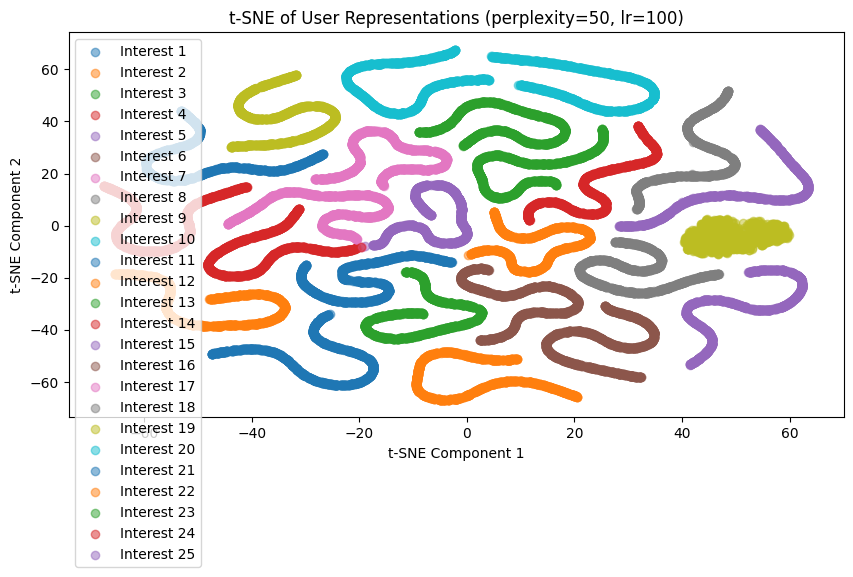

Running t-SNE with perplexity=50 and learning_rate=400


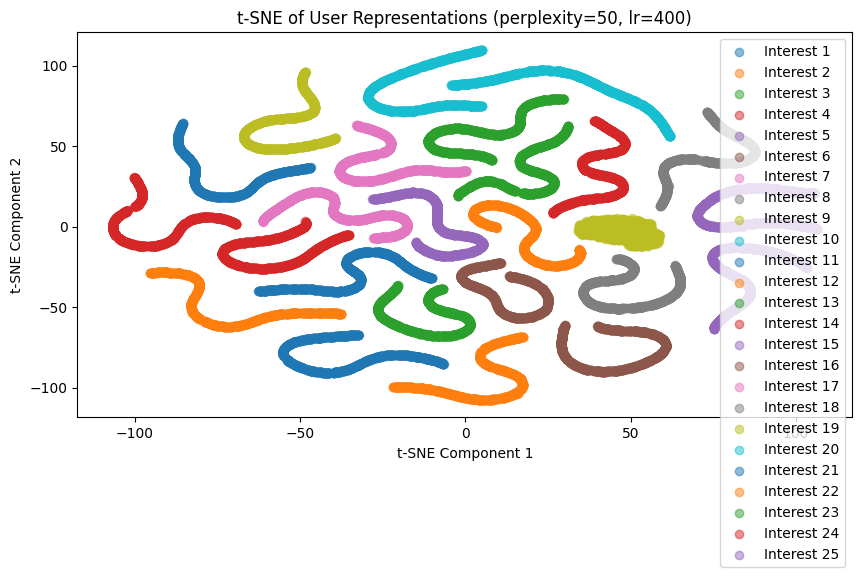

Running t-SNE with perplexity=60 and learning_rate=500


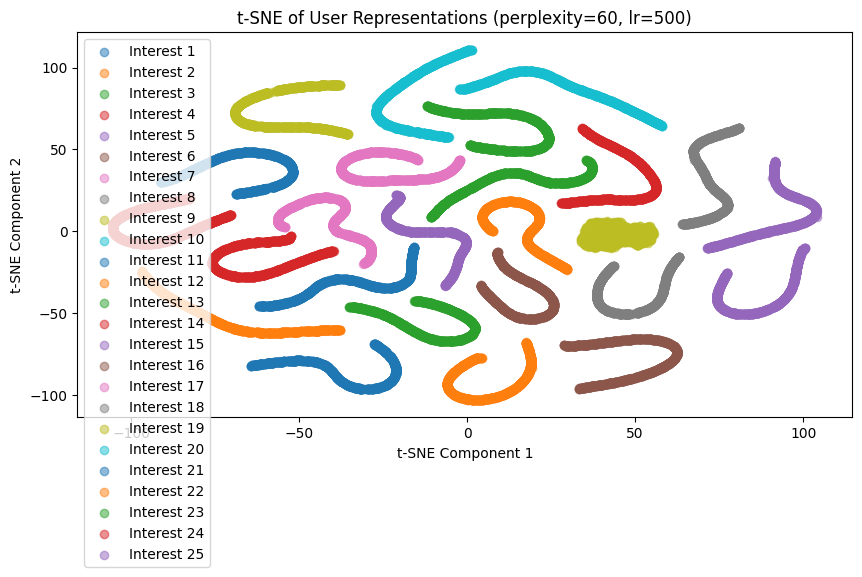

In [3]:
#t-SNE and PCA plots for N=25 (without disentanglement loss)
pickle_file_path = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/user_representations.pkl'
with open(pickle_file_path, 'rb') as f:
    user_representations = pickle.load(f)

# Define t-SNE parameter combinations
combinations = [(10,50), (20,300),(30, 200), (40,150), (40, 300), (50,100), (50, 400), (60, 500)]

# Plot t-SNE and PCA for each combination
for perplexity, learning_rate in combinations:
    print(f"Running t-SNE with perplexity={perplexity} and learning_rate={learning_rate}")
    plot_tsne(user_representations, perplexity, learning_rate)

Running t-SNE with perplexity=10 and learning_rate=50


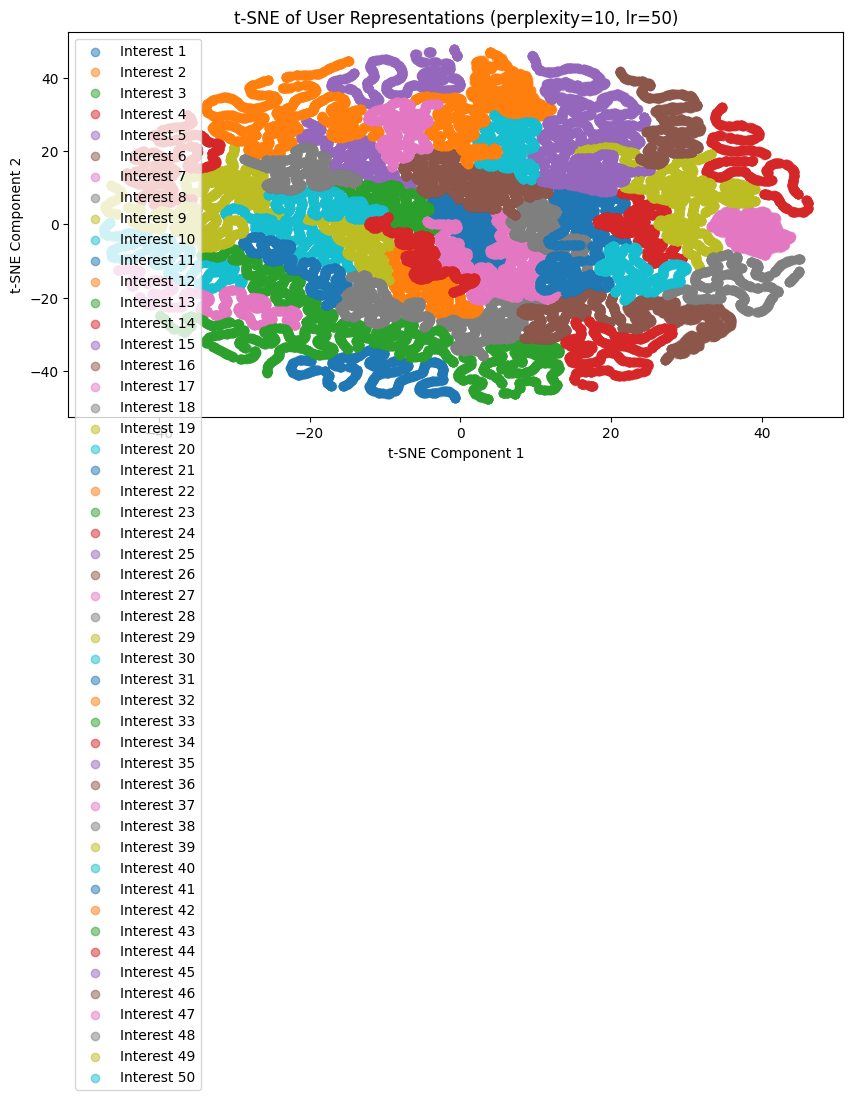

Running t-SNE with perplexity=20 and learning_rate=300


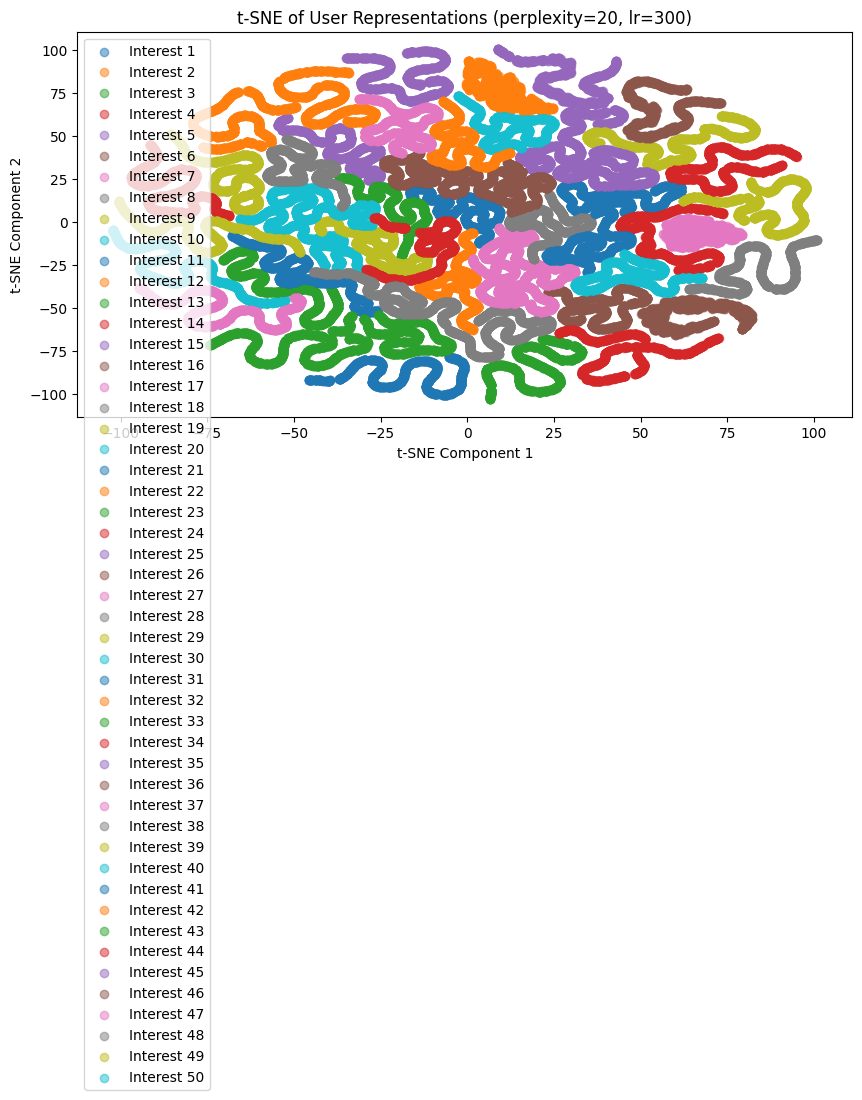

Running t-SNE with perplexity=30 and learning_rate=200


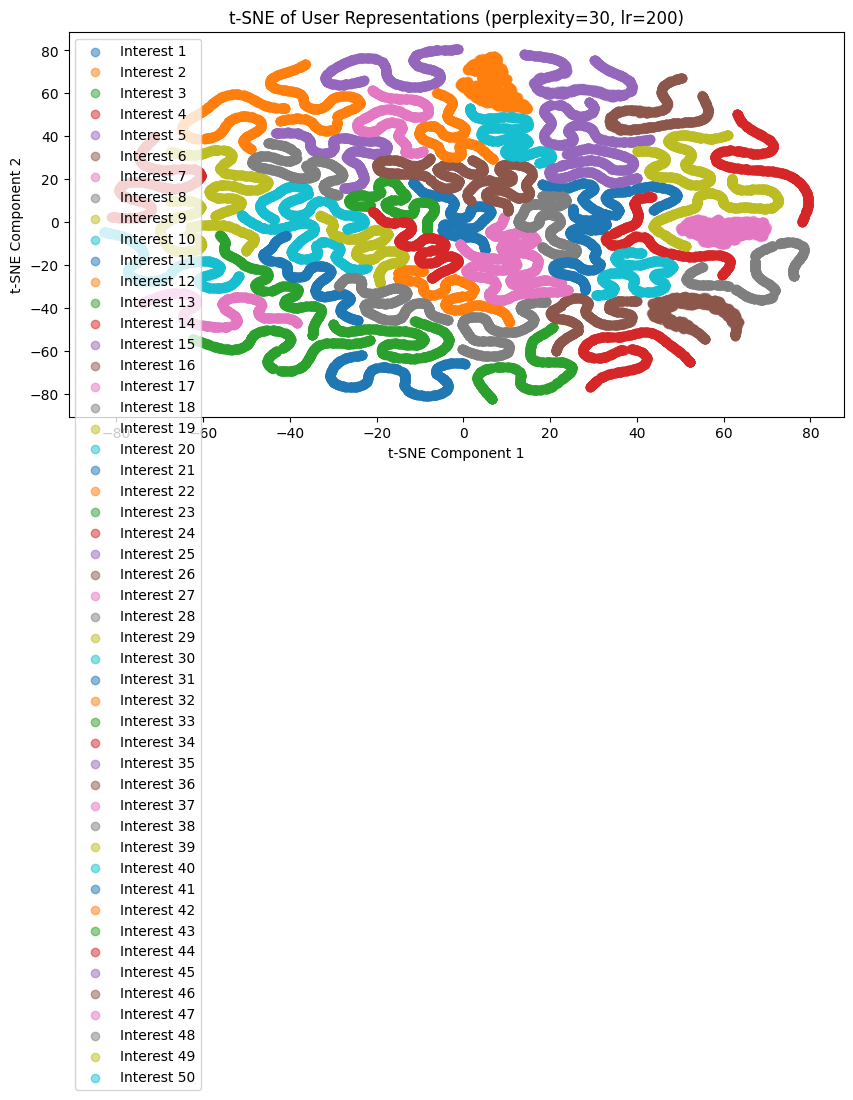

Running t-SNE with perplexity=40 and learning_rate=150


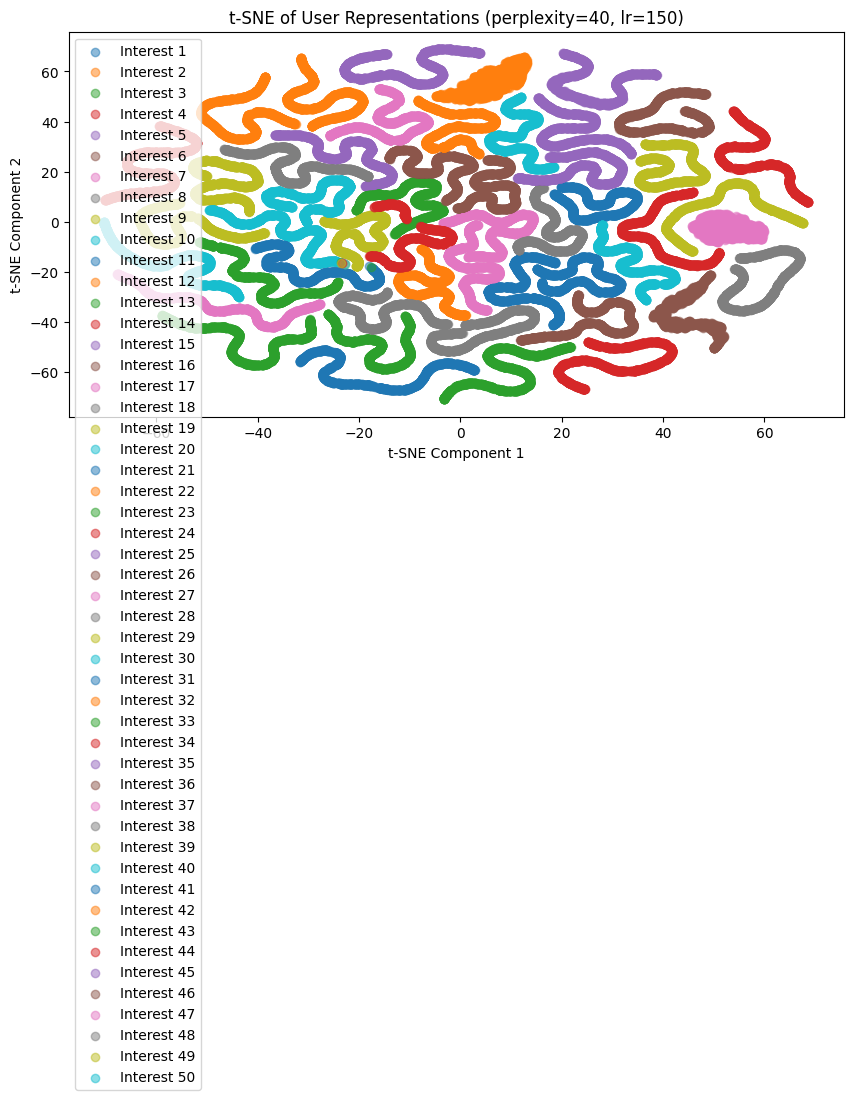

Running t-SNE with perplexity=40 and learning_rate=300


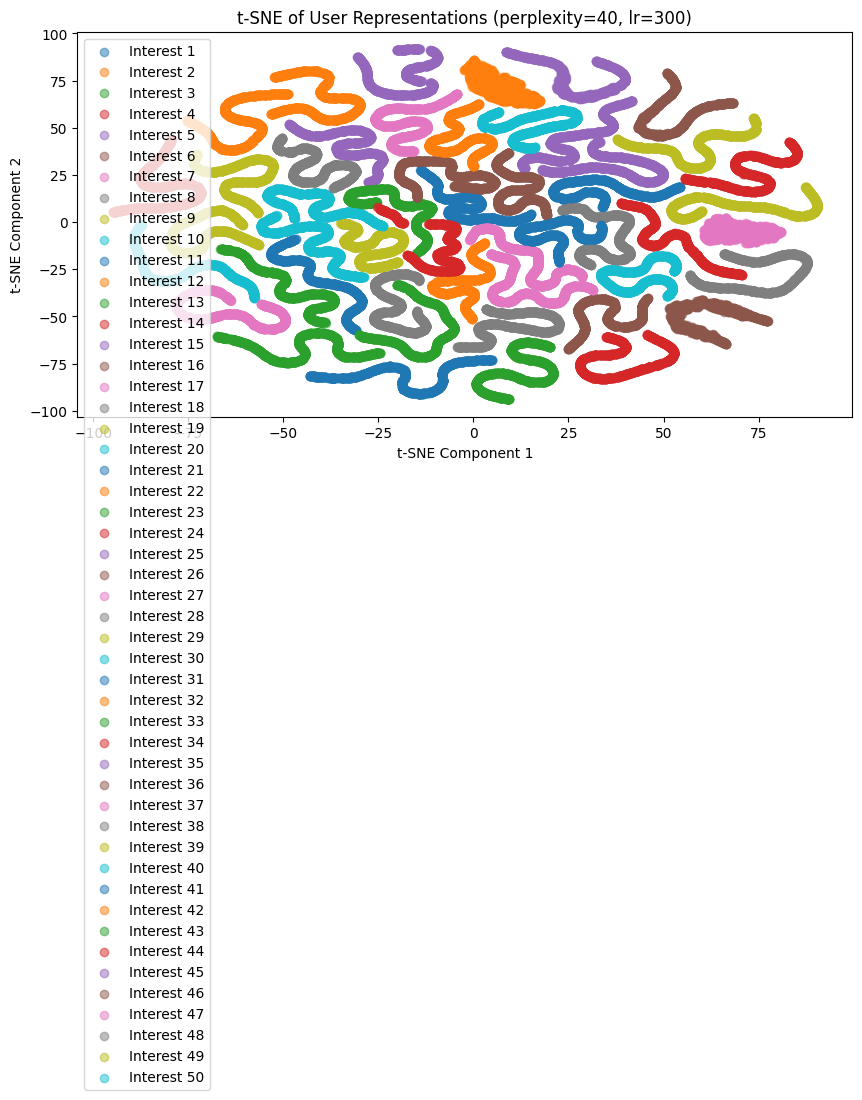

Running t-SNE with perplexity=50 and learning_rate=100


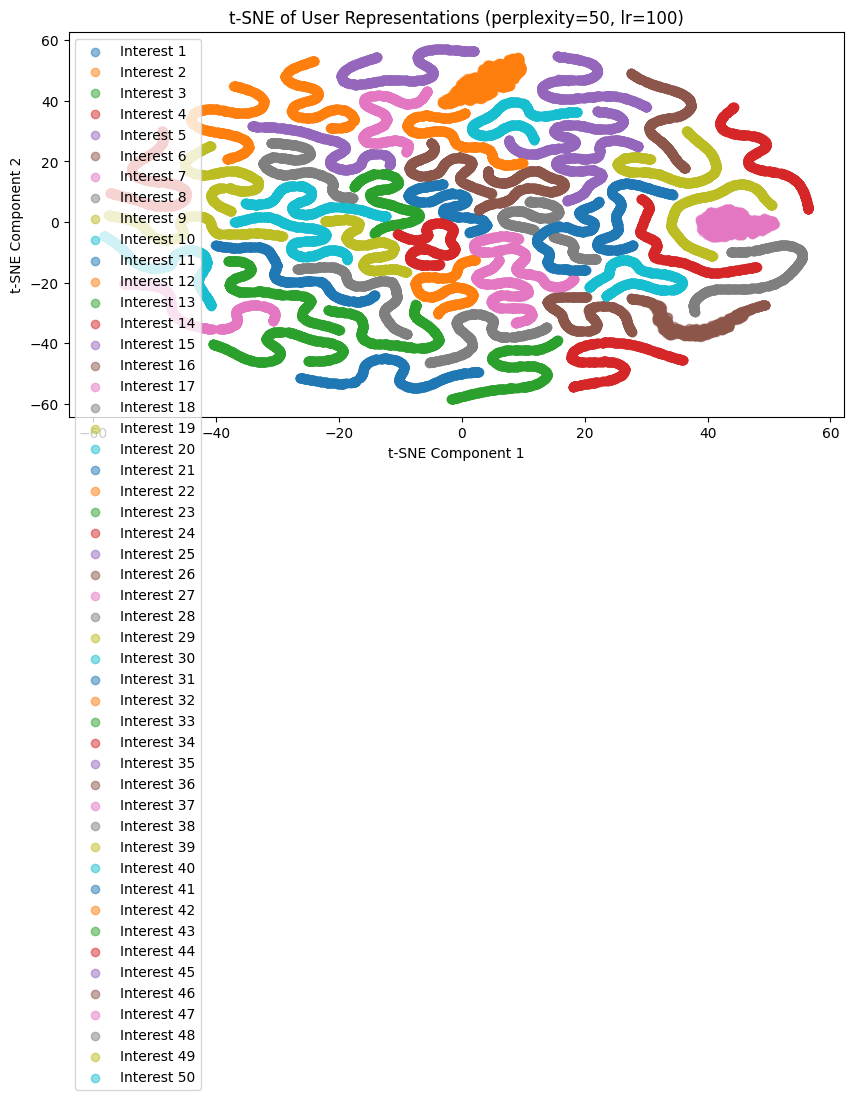

Running t-SNE with perplexity=50 and learning_rate=400


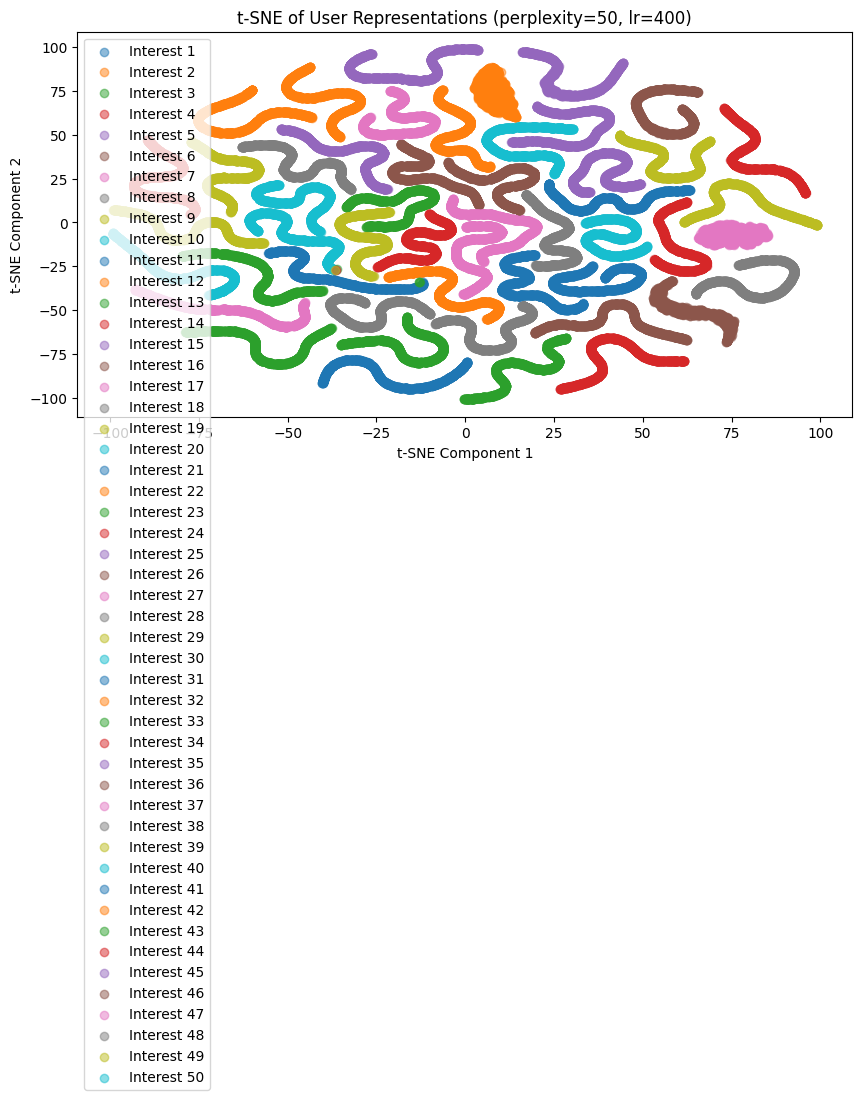

Running t-SNE with perplexity=60 and learning_rate=500


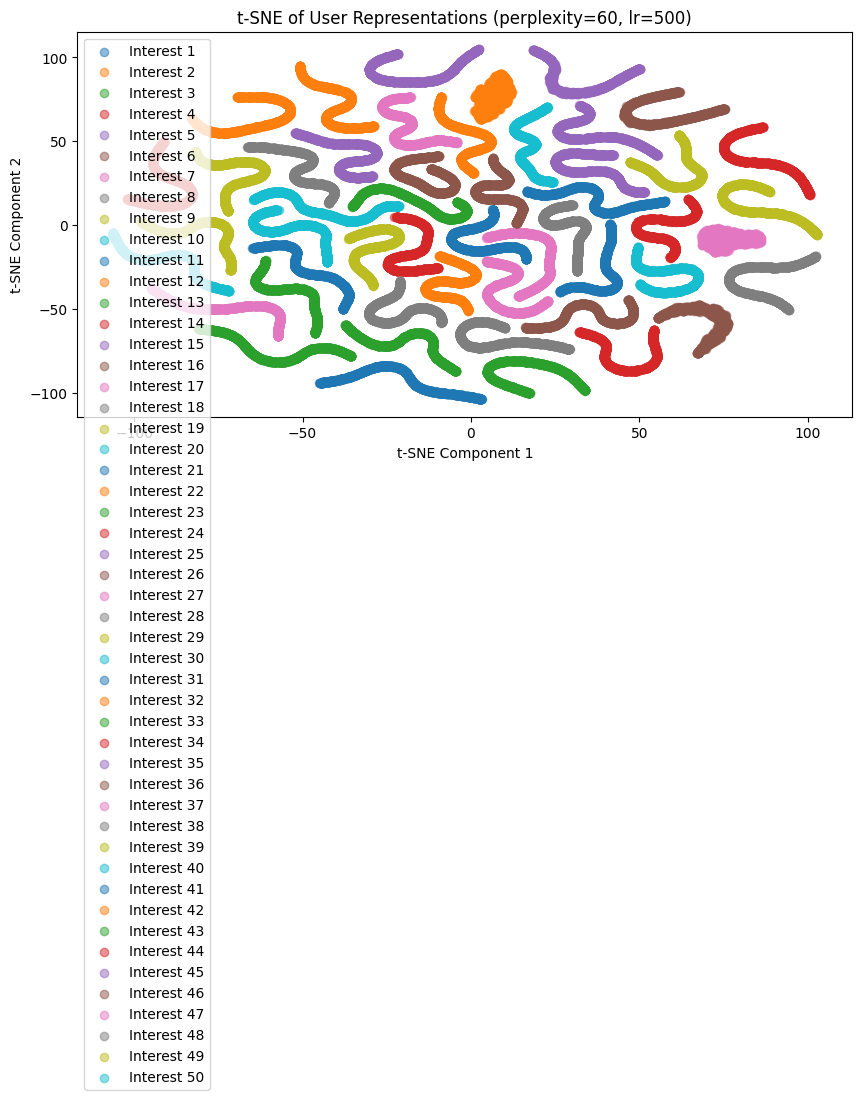

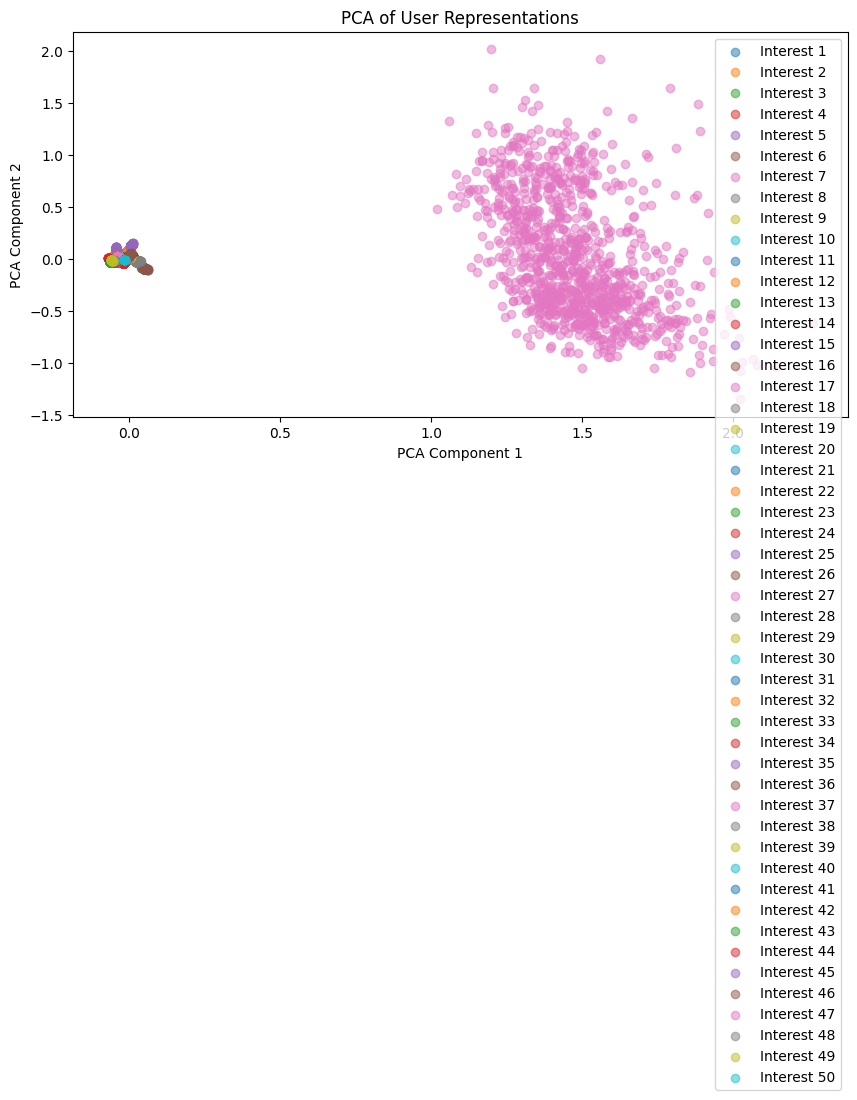

In [4]:
#t-SNE and PCA plots for N=50 (without disentanglement loss)
pickle_file_path = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/user_representations.pkl'
with open(pickle_file_path, 'rb') as f:
    user_representations = pickle.load(f)

# Define t-SNE parameter combinations
combinations = [(10,50), (20,300),(30, 200), (40,150), (40, 300), (50,100), (50, 400), (60, 500)]

# Plot t-SNE and PCA for each combination
for perplexity, learning_rate in combinations:
    print(f"Running t-SNE with perplexity={perplexity} and learning_rate={learning_rate}")
    plot_tsne(user_representations, perplexity, learning_rate)

plot_pca(user_representations)